In [ ]:


# ============================================================
# PART 1 - PROJECT SETUP AND DATASET LOADING
# ============================================================


# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================



import pandas as pd
import numpy as np

In [ ]:
# ============================================================
# 2. FUNCTION: LOAD DATASET
# ============================================================

def load_dataset(file_path):

    """
    Load a CSV or Excel dataset.

    Parameters
    ----------
    file_path : str
        Location of the dataset.

    Returns
    -------
    pandas.DataFrame
        Loaded dataset.
    """

    # --------------------------------------------------------
    # CHECK FOR CSV FILE
    # --------------------------------------------------------

    if file_path.lower().endswith(".csv"):

        data = pd.read_csv(file_path)


    # --------------------------------------------------------
    # CHECK FOR EXCEL FILE
    # --------------------------------------------------------

    elif file_path.lower().endswith(".xlsx"):

        data = pd.read_excel(file_path)


    # --------------------------------------------------------
    # UNSUPPORTED FILE TYPE
    # --------------------------------------------------------

    else:

        raise ValueError(
            "Unsupported file format. "
            "Please provide a CSV or XLSX file."
        )


    # --------------------------------------------------------
    # CHECK WHETHER DATASET IS EMPTY
    # --------------------------------------------------------

    if data.empty:

        raise ValueError(
            "The dataset is empty."
        )


    return data

In [ ]:
# ============================================================
# 3. FUNCTION: INSPECT DATASET
# ============================================================

def inspect_dataset(data):

    """
    Display basic information about the dataset.
    """

    # --------------------------------------------------------
    # DATASET PREVIEW
    # --------------------------------------------------------

    print("First 5 Rows:")

    display(data.head())


    # --------------------------------------------------------
    # DATASET SHAPE
    # --------------------------------------------------------

    print("\nDataset Shape:")
    print(data.shape)

    print("\nNumber of Rows:")
    print(data.shape[0])

    print("\nNumber of Columns:")
    print(data.shape[1])


    # --------------------------------------------------------
    # COLUMN NAMES
    # --------------------------------------------------------

    print("\nColumn Names:")

    print(data.columns.tolist())


    # --------------------------------------------------------
    # DATA TYPES
    # --------------------------------------------------------

    print("\nData Types:")

    print(data.dtypes)


    # --------------------------------------------------------
    # DATASET INFORMATION
    # --------------------------------------------------------

    print("\nDataset Information:")

    data.info()

In [ ]:
# ============================================================
# 4. FUNCTION: CHECK DATA QUALITY
# ============================================================

def check_data_quality(data):

    """
    Check common data quality problems in the dataset.
    """

    # --------------------------------------------------------
    # MISSING VALUES
    # --------------------------------------------------------

    print("Missing Values Per Column:")

    print(
        data.isnull().sum()
    )


    # --------------------------------------------------------
    # TOTAL MISSING VALUES
    # --------------------------------------------------------

    print("\nTotal Missing Values:")

    print(
        data.isnull().sum().sum()
    )


    # --------------------------------------------------------
    # DUPLICATE ROWS
    # --------------------------------------------------------

    duplicate_rows = data.duplicated().sum()

    print("\nDuplicate Rows:")

    print(
        duplicate_rows
    )


    # --------------------------------------------------------
    # UNIQUE VALUES PER COLUMN
    # --------------------------------------------------------

    print("\nUnique Values Per Column:")

    print(
        data.nunique()
    )

In [ ]:
# ============================================================
# 5. FUNCTION: IDENTIFY COLUMN TYPES
# ============================================================

def identify_column_types(data):

    """
    Identify numerical, categorical, and datetime columns.
    """

    # --------------------------------------------------------
    # NUMERICAL COLUMNS
    # --------------------------------------------------------

    numerical_columns = data.select_dtypes(
        include="number"
    ).columns.tolist()


    # --------------------------------------------------------
    # CATEGORICAL COLUMNS
    # --------------------------------------------------------

    categorical_columns = data.select_dtypes(
        include=[
            "object",
            "category",
            "string",
            "bool"
        ]
    ).columns.tolist()


    # --------------------------------------------------------
    # DATETIME COLUMNS
    # --------------------------------------------------------

    datetime_columns = data.select_dtypes(
        include=[
            "datetime",
            "datetimetz"
        ]
    ).columns.tolist()


    # --------------------------------------------------------
    # DISPLAY RESULTS
    # --------------------------------------------------------

    print("Numerical Columns:")
    print(numerical_columns)

    print("\nCategorical Columns:")
    print(categorical_columns)

    print("\nDatetime Columns:")
    print(datetime_columns)


    # --------------------------------------------------------
    # RETURN RESULTS
    # --------------------------------------------------------

    return (
        numerical_columns,
        categorical_columns,
        datetime_columns
    )

In [ ]:
# ============================================================
# 6. FUNCTION: DETECT IDENTIFIER COLUMNS
# ============================================================

def detect_identifier_columns(data):

    """
    Detect columns that are likely to be identifiers,
    such as customer_id, order_id, employee_id, etc.
    """

    identifier_columns = []


    # --------------------------------------------------------
    # CHECK EACH COLUMN NAME
    # --------------------------------------------------------

    for column in data.columns:

        column_name = str(column).lower()


        # Common identifier naming patterns
        if (
            column_name == "id"
            or column_name.endswith("_id")
            or column_name.startswith("id_")
            or column_name.endswith("_identifier")
        ):

            identifier_columns.append(column)


    # --------------------------------------------------------
    # DISPLAY RESULTS
    # --------------------------------------------------------

    print("Likely Identifier Columns:")
    print(identifier_columns)


    # --------------------------------------------------------
    # RETURN RESULTS
    # --------------------------------------------------------

    return identifier_columns

In [ ]:
# ============================================================
# 7. FUNCTION: STANDARDIZE COLUMN NAMES
# ============================================================

def standardize_column_names(data):

    """
    Standardize column names so they are easier to use
    during analysis, visualization, and machine learning.
    """

    # Create a copy of the dataset
    cleaned_data = data.copy()


    # --------------------------------------------------------
    # STANDARDIZE COLUMN NAMES
    # --------------------------------------------------------

    cleaned_data.columns = (
        cleaned_data.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )


    # --------------------------------------------------------
    # CHECK FOR DUPLICATE COLUMN NAMES
    # --------------------------------------------------------

    if cleaned_data.columns.duplicated().any():

        raise ValueError(
            "Duplicate column names found after standardization."
        )


    # --------------------------------------------------------
    # DISPLAY UPDATED COLUMN NAMES
    # --------------------------------------------------------

    print("Standardized Column Names:")

    print(
        cleaned_data.columns.tolist()
    )


    # --------------------------------------------------------
    # RETURN CLEANED DATASET
    # --------------------------------------------------------

    return cleaned_data

In [ ]:
# ============================================================
# 8. FUNCTION: REMOVE DUPLICATE ROWS
# ============================================================

def remove_duplicate_rows(data):

    """
    Detect and remove exact duplicate rows.
    """

    # Create a copy
    cleaned_data = data.copy()


    # --------------------------------------------------------
    # COUNT DUPLICATES
    # --------------------------------------------------------

    duplicate_count = cleaned_data.duplicated().sum()


    # --------------------------------------------------------
    # REMOVE DUPLICATES
    # --------------------------------------------------------

    cleaned_data = cleaned_data.drop_duplicates().copy()


    # --------------------------------------------------------
    # RESET INDEX
    # --------------------------------------------------------

    cleaned_data = cleaned_data.reset_index(drop=True)


    # --------------------------------------------------------
    # DISPLAY RESULT
    # --------------------------------------------------------

    print("Duplicate Rows Found:")
    print(duplicate_count)


    # --------------------------------------------------------
    # RETURN RESULT
    # --------------------------------------------------------

    return cleaned_data, duplicate_count

In [ ]:
# ============================================================
# 9. FUNCTION: CHECK MISSING VALUES
# ============================================================

def check_missing_values(data):

    """
    Check the number and percentage of missing values
    in each column.
    """

    # --------------------------------------------------------
    # COUNT MISSING VALUES
    # --------------------------------------------------------

    missing_count = data.isnull().sum()


    # --------------------------------------------------------
    # CALCULATE MISSING VALUE PERCENTAGE
    # --------------------------------------------------------

    missing_percentage = (
        missing_count / len(data) * 100
    ).round(2)


    # --------------------------------------------------------
    # CREATE MISSING VALUE REPORT
    # --------------------------------------------------------

    missing_report = pd.DataFrame({

        "Column": data.columns,

        "Missing Values": missing_count.values,

        "Missing Percentage": missing_percentage.values

    })


    # --------------------------------------------------------
    # SORT BY HIGHEST MISSING VALUES
    # --------------------------------------------------------

    missing_report = missing_report.sort_values(
        by="Missing Values",
        ascending=False
    ).reset_index(drop=True)


    # --------------------------------------------------------
    # DISPLAY REPORT
    # --------------------------------------------------------

    display(missing_report)


    # --------------------------------------------------------
    # RETURN REPORT
    # --------------------------------------------------------

    return missing_report

In [ ]:
# ============================================================
# 10. FUNCTION: REPLACE MISSING VALUE PLACEHOLDERS
# ============================================================

def replace_missing_placeholders(data):

    """
    Replace common text placeholders that represent
    missing values with NumPy NaN.
    """

    # Create a copy
    cleaned_data = data.copy()


    # --------------------------------------------------------
    # COMMON MISSING VALUE PLACEHOLDERS
    # --------------------------------------------------------

    missing_placeholders = [
        "?",
        "NA",
        "N/A",
        "na",
        "n/a",
        "null",
        "NULL",
        "None",
        "none",
        "",
        " "
    ]


    # --------------------------------------------------------
    # REPLACE PLACEHOLDERS WITH NaN
    # --------------------------------------------------------

    cleaned_data = cleaned_data.replace(
        missing_placeholders,
        np.nan
    )


    # --------------------------------------------------------
    # DISPLAY RESULT
    # --------------------------------------------------------

    print("Missing value placeholders replaced successfully.")


    # --------------------------------------------------------
    # RETURN CLEANED DATASET
    # --------------------------------------------------------

    return cleaned_data

In [ ]:
# ============================================================
# 11. FUNCTION: FILL MISSING VALUES
# ============================================================

def fill_missing_values(data):

    """
    Fill missing values in numerical and categorical columns.
    """

    # Create a copy
    cleaned_data = data.copy()


    # --------------------------------------------------------
    # IDENTIFY NUMERICAL COLUMNS
    # --------------------------------------------------------

    numerical_columns = cleaned_data.select_dtypes(
        include="number"
    ).columns.tolist()


    # --------------------------------------------------------
    # IDENTIFY CATEGORICAL COLUMNS
    # --------------------------------------------------------

    categorical_columns = cleaned_data.select_dtypes(
        include=[
            "object",
            "category",
            "string",
            "bool"
        ]
    ).columns.tolist()


    # --------------------------------------------------------
    # FILL NUMERICAL MISSING VALUES WITH MEDIAN
    # --------------------------------------------------------

    for column in numerical_columns:

        if cleaned_data[column].isnull().any():

            median_value = cleaned_data[column].median()

            cleaned_data[column] = cleaned_data[column].fillna(
                median_value
            )


    # --------------------------------------------------------
    # FILL CATEGORICAL MISSING VALUES WITH MODE
    # --------------------------------------------------------

    for column in categorical_columns:

        if cleaned_data[column].isnull().any():

            mode_values = cleaned_data[column].mode()

            if not mode_values.empty:

                cleaned_data[column] = cleaned_data[column].fillna(
                    mode_values[0]
                )


    # --------------------------------------------------------
    # DISPLAY RESULT
    # --------------------------------------------------------

    print("Missing values filled successfully.")


    # --------------------------------------------------------
    # RETURN CLEANED DATASET
    # --------------------------------------------------------

    return cleaned_data

In [ ]:
# ============================================================
# 12. FUNCTION: DETECT DATE COLUMNS
# ============================================================

def detect_date_columns(data):

    """
    Detect columns that are likely to contain dates
    and convert them to datetime format.
    """

    # Create a copy
    cleaned_data = data.copy()

    date_columns = []


    # --------------------------------------------------------
    # CHECK EACH COLUMN
    # --------------------------------------------------------

    for column in cleaned_data.columns:

        column_name = str(column).lower()


        # ----------------------------------------------------
        # CHECK COLUMN NAME FOR DATE-RELATED WORDS
        # ----------------------------------------------------

        if (
            "date" in column_name
            or "datetime" in column_name
            or "timestamp" in column_name
        ):

            # Try converting the column to datetime
            converted_column = pd.to_datetime(
                cleaned_data[column],
                errors="coerce"
            )


            # ------------------------------------------------
            # CHECK WHETHER CONVERSION WAS SUCCESSFUL
            # ------------------------------------------------

            valid_values = converted_column.notnull().sum()

            original_values = cleaned_data[column].notnull().sum()


            if (
                original_values > 0
                and valid_values == original_values
            ):

                cleaned_data[column] = converted_column

                date_columns.append(column)


    # --------------------------------------------------------
    # DISPLAY RESULT
    # --------------------------------------------------------

    print("Detected Date Columns:")
    print(date_columns)


    # --------------------------------------------------------
    # RETURN RESULTS
    # --------------------------------------------------------

    return cleaned_data, date_columns

In [ ]:
# ============================================================
# 13. FUNCTION: DETECT OUTLIERS USING IQR
# ============================================================

def detect_outliers(data):

    """
    Detect outliers in numerical columns using
    the Interquartile Range (IQR) method.
    """

    # --------------------------------------------------------
    # IDENTIFY NUMERICAL COLUMNS
    # --------------------------------------------------------

    numerical_columns = data.select_dtypes(
        include="number"
    ).columns.tolist()


    # --------------------------------------------------------
    # CREATE EMPTY OUTLIER REPORT
    # --------------------------------------------------------

    outlier_report = []


    # --------------------------------------------------------
    # CHECK EACH NUMERICAL COLUMN
    # --------------------------------------------------------

    for column in numerical_columns:

        values = data[column].dropna()


        # Skip columns with no values
        if values.empty:

            continue


        # ----------------------------------------------------
        # CALCULATE Q1 AND Q3
        # ----------------------------------------------------

        q1 = values.quantile(0.25)

        q3 = values.quantile(0.75)


        # ----------------------------------------------------
        # CALCULATE IQR
        # ----------------------------------------------------

        iqr = q3 - q1


        # ----------------------------------------------------
        # CALCULATE LOWER AND UPPER LIMITS
        # ----------------------------------------------------

        lower_limit = q1 - (1.5 * iqr)

        upper_limit = q3 + (1.5 * iqr)


        # ----------------------------------------------------
        # FIND OUTLIERS
        # ----------------------------------------------------

        outliers = values[
            (values < lower_limit)
            |
            (values > upper_limit)
        ]


        # ----------------------------------------------------
        # SAVE RESULT
        # ----------------------------------------------------

        outlier_report.append({

            "Column": column,

            "Outlier Count": len(outliers),

            "Lower Limit": lower_limit,

            "Upper Limit": upper_limit

        })


    # --------------------------------------------------------
    # CONVERT REPORT TO DATAFRAME
    # --------------------------------------------------------

    outlier_report = pd.DataFrame(
        outlier_report
    )


    # --------------------------------------------------------
    # DISPLAY REPORT
    # --------------------------------------------------------

    display(outlier_report)


    # --------------------------------------------------------
    # RETURN REPORT
    # --------------------------------------------------------

    return outlier_report

In [ ]:
# ============================================================
# 14. FUNCTION: CAP OUTLIERS USING IQR
# ============================================================

def cap_outliers(data):

    """
    Cap outliers in numerical columns using
    the Interquartile Range (IQR) method.
    """

    # Create a copy
    cleaned_data = data.copy()


    # --------------------------------------------------------
    # IDENTIFY NUMERICAL COLUMNS
    # --------------------------------------------------------

    numerical_columns = cleaned_data.select_dtypes(
        include="number"
    ).columns.tolist()


    # --------------------------------------------------------
    # DETECT IDENTIFIER COLUMNS
    # --------------------------------------------------------

    identifier_columns = detect_identifier_columns(
        cleaned_data
    )


    # --------------------------------------------------------
    # CHECK EACH NUMERICAL COLUMN
    # --------------------------------------------------------

    for column in numerical_columns:

        # Do not modify identifier columns
        if column in identifier_columns:

            continue


        values = cleaned_data[column].dropna()


        # Skip empty columns
        if values.empty:

            continue


        # ----------------------------------------------------
        # CALCULATE Q1 AND Q3
        # ----------------------------------------------------

        q1 = values.quantile(0.25)

        q3 = values.quantile(0.75)


        # ----------------------------------------------------
        # CALCULATE IQR
        # ----------------------------------------------------

        iqr = q3 - q1


        # ----------------------------------------------------
        # CALCULATE LIMITS
        # ----------------------------------------------------

        lower_limit = q1 - (1.5 * iqr)

        upper_limit = q3 + (1.5 * iqr)


        # ----------------------------------------------------
        # CAP OUTLIERS
        # ----------------------------------------------------

        cleaned_data[column] = cleaned_data[column].clip(
            lower=lower_limit,
            upper=upper_limit
        )


    # --------------------------------------------------------
    # DISPLAY RESULT
    # --------------------------------------------------------

    print("Outlier capping completed successfully.")


    # --------------------------------------------------------
    # RETURN CLEANED DATASET
    # --------------------------------------------------------

    return cleaned_data

In [ ]:
# ============================================================
# 15. FUNCTION: COMPLETE DATA CLEANING PIPELINE
# ============================================================

def clean_dataset(data):

    """
    Run the main data cleaning steps in sequence.

    Steps:
    1. Standardize column names
    2. Remove duplicate rows
    3. Replace missing-value placeholders
    4. Detect and convert date columns
    5. Fill missing values
    6. Cap numerical outliers
    """

    # Create a copy of the original dataset
    cleaned_data = data.copy()


    # --------------------------------------------------------
    # STEP 1: STANDARDIZE COLUMN NAMES
    # --------------------------------------------------------

    cleaned_data = standardize_column_names(
        cleaned_data
    )


    # --------------------------------------------------------
    # STEP 2: REMOVE DUPLICATE ROWS
    # --------------------------------------------------------

    cleaned_data, duplicate_count = remove_duplicate_rows(
        cleaned_data
    )


    # --------------------------------------------------------
    # STEP 3: REPLACE MISSING VALUE PLACEHOLDERS
    # --------------------------------------------------------

    cleaned_data = replace_missing_placeholders(
        cleaned_data
    )


    # --------------------------------------------------------
    # STEP 4: DETECT DATE COLUMNS
    # --------------------------------------------------------

    cleaned_data, date_columns = detect_date_columns(
        cleaned_data
    )


    # --------------------------------------------------------
    # STEP 5: FILL MISSING VALUES
    # --------------------------------------------------------

    cleaned_data = fill_missing_values(
        cleaned_data
    )


    # --------------------------------------------------------
    # STEP 6: CAP OUTLIERS
    # --------------------------------------------------------

    cleaned_data = cap_outliers(
        cleaned_data
    )


    # --------------------------------------------------------
    # DISPLAY CLEANING SUMMARY
    # --------------------------------------------------------

    print("\nCleaning Completed")

    print("\nDuplicate Rows Removed:")
    print(duplicate_count)

    print("\nDetected Date Columns:")
    print(date_columns)

    print("\nRemaining Missing Values:")
    print(
        cleaned_data.isnull().sum().sum()
    )


    # --------------------------------------------------------
    # RETURN CLEANED DATASET
    # --------------------------------------------------------

    return cleaned_data

In [ ]:
# ============================================================
# 16. FUNCTION: VALIDATE CLEANED DATASET
# ============================================================

def validate_cleaned_dataset(data):

    """
    Validate the cleaned dataset after the cleaning pipeline.
    """

    # --------------------------------------------------------
    # CHECK DATASET SHAPE
    # --------------------------------------------------------

    print("Cleaned Dataset Shape:")
    print(data.shape)


    # --------------------------------------------------------
    # CHECK REMAINING MISSING VALUES
    # --------------------------------------------------------

    print("\nRemaining Missing Values:")

    print(
        data.isnull().sum()
    )


    # --------------------------------------------------------
    # CHECK TOTAL MISSING VALUES
    # --------------------------------------------------------

    print("\nTotal Remaining Missing Values:")

    print(
        data.isnull().sum().sum()
    )


    # --------------------------------------------------------
    # CHECK DUPLICATE ROWS
    # --------------------------------------------------------

    print("\nRemaining Duplicate Rows:")

    print(
        data.duplicated().sum()
    )


    # --------------------------------------------------------
    # CHECK FINAL DATA TYPES
    # --------------------------------------------------------

    print("\nFinal Data Types:")

    print(
        data.dtypes
    )


    # --------------------------------------------------------
    # DISPLAY CLEANED DATA PREVIEW
    # --------------------------------------------------------

    print("\nCleaned Dataset Preview:")

    display(
        data.head()
    )

In [ ]:
# ============================================================
# PART 2 - EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================


# ============================================================
# 17. FUNCTION: BASIC STATISTICAL SUMMARY
# ============================================================

def basic_statistical_summary(data):

    """
    Display descriptive statistics for numerical columns.
    """

    # --------------------------------------------------------
    # SELECT NUMERICAL COLUMNS
    # --------------------------------------------------------

    numerical_data = data.select_dtypes(
        include="number"
    )


    # --------------------------------------------------------
    # CHECK IF NUMERICAL COLUMNS EXIST
    # --------------------------------------------------------

    if numerical_data.empty:

        print(
            "No numerical columns found in the dataset."
        )

        return None


    # --------------------------------------------------------
    # DESCRIPTIVE STATISTICS
    # --------------------------------------------------------

    summary = numerical_data.describe()


    # --------------------------------------------------------
    # DISPLAY SUMMARY
    # --------------------------------------------------------

    print("Numerical Statistical Summary:")

    display(
        summary
    )


    # --------------------------------------------------------
    # RETURN SUMMARY
    # --------------------------------------------------------

    return summary

In [ ]:
# ============================================================
# 18. FUNCTION: CATEGORICAL SUMMARY
# ============================================================

def categorical_summary(data):

    """
    Display basic information for categorical columns.
    """

    # --------------------------------------------------------
    # SELECT CATEGORICAL COLUMNS
    # --------------------------------------------------------

    categorical_columns = data.select_dtypes(
        include=[
            "object",
            "category",
            "string",
            "bool"
        ]
    ).columns.tolist()


    # --------------------------------------------------------
    # CHECK IF CATEGORICAL COLUMNS EXIST
    # --------------------------------------------------------

    if len(categorical_columns) == 0:

        print(
            "No categorical columns found in the dataset."
        )

        return None


    # --------------------------------------------------------
    # CREATE SUMMARY
    # --------------------------------------------------------

    summary_rows = []


    for column in categorical_columns:

        summary_rows.append({

            "Column": column,

            "Unique Values": data[column].nunique(
                dropna=True
            ),

            "Most Frequent Value": (
                data[column].mode().iloc[0]
                if not data[column].mode().empty
                else None
            ),

            "Most Frequent Count": (
                data[column].value_counts(
                    dropna=True
                ).iloc[0]
                if not data[column].value_counts(
                    dropna=True
                ).empty
                else 0
            )

        })


    # --------------------------------------------------------
    # CONVERT TO DATAFRAME
    # --------------------------------------------------------

    categorical_report = pd.DataFrame(
        summary_rows
    )


    # --------------------------------------------------------
    # DISPLAY SUMMARY
    # --------------------------------------------------------

    print("Categorical Summary:")

    display(
        categorical_report
    )


    # --------------------------------------------------------
    # RETURN SUMMARY
    # --------------------------------------------------------

    return categorical_report

In [ ]:
# ============================================================
# 19. FUNCTION: CORRELATION ANALYSIS
# ============================================================

def correlation_analysis(data):

    """
    Calculate the correlation matrix for numerical columns.
    """

    # --------------------------------------------------------
    # SELECT NUMERICAL COLUMNS
    # --------------------------------------------------------

    numerical_data = data.select_dtypes(
        include="number"
    )


    # --------------------------------------------------------
    # CHECK IF ENOUGH NUMERICAL COLUMNS EXIST
    # --------------------------------------------------------

    if numerical_data.shape[1] < 2:

        print(
            "At least two numerical columns are required "
            "for correlation analysis."
        )

        return None


    # --------------------------------------------------------
    # CALCULATE CORRELATION MATRIX
    # --------------------------------------------------------

    correlation_matrix = numerical_data.corr()


    # --------------------------------------------------------
    # DISPLAY CORRELATION MATRIX
    # --------------------------------------------------------

    print("Correlation Matrix:")

    display(
        correlation_matrix
    )


    # --------------------------------------------------------
    # RETURN CORRELATION MATRIX
    # --------------------------------------------------------

    return correlation_matrix

In [ ]:
# ============================================================
# PART 3 - DATA VISUALIZATION
# ============================================================


# ============================================================
# 20. IMPORT VISUALIZATION LIBRARIES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ============================================================
# 21. FUNCTION: HISTOGRAM
# ============================================================

def plot_histogram(data, column):

    """
    Plot the distribution of a numerical column.
    """

    # --------------------------------------------------------
    # CHECK WHETHER COLUMN EXISTS
    # --------------------------------------------------------

    if column not in data.columns:

        raise ValueError(
            f"Column '{column}' does not exist in the dataset."
        )


    # --------------------------------------------------------
    # CHECK WHETHER COLUMN IS NUMERICAL
    # --------------------------------------------------------

    if not pd.api.types.is_numeric_dtype(
        data[column]
    ):

        raise ValueError(
            f"Column '{column}' is not numerical."
        )


    # --------------------------------------------------------
    # REMOVE MISSING VALUES
    # --------------------------------------------------------

    values = data[column].dropna()


    # --------------------------------------------------------
    # CREATE HISTOGRAM
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    sns.histplot(
        values,
        bins=20,
        kde=True
    )


    # --------------------------------------------------------
    # ADD TITLE AND LABELS
    # --------------------------------------------------------

    plt.title(
        f"Distribution of {column}"
    )

    plt.xlabel(
        column
    )

    plt.ylabel(
        "Frequency"
    )


    # --------------------------------------------------------
    # DISPLAY PLOT
    # --------------------------------------------------------

    plt.show()

In [ ]:
# ============================================================
# 22. FUNCTION: SCATTER PLOT
# ============================================================

def plot_scatter(data, x_column, y_column):

    """
    Plot the relationship between two numerical columns.
    """

    # --------------------------------------------------------
    # CHECK WHETHER COLUMNS EXIST
    # --------------------------------------------------------

    if x_column not in data.columns:

        raise ValueError(
            f"Column '{x_column}' does not exist in the dataset."
        )

    if y_column not in data.columns:

        raise ValueError(
            f"Column '{y_column}' does not exist in the dataset."
        )


    # --------------------------------------------------------
    # CHECK WHETHER BOTH COLUMNS ARE NUMERICAL
    # --------------------------------------------------------

    if not pd.api.types.is_numeric_dtype(
        data[x_column]
    ):

        raise ValueError(
            f"Column '{x_column}' is not numerical."
        )

    if not pd.api.types.is_numeric_dtype(
        data[y_column]
    ):

        raise ValueError(
            f"Column '{y_column}' is not numerical."
        )


    # --------------------------------------------------------
    # CREATE SCATTER PLOT
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    sns.scatterplot(
        data=data,
        x=x_column,
        y=y_column
    )


    # --------------------------------------------------------
    # ADD TITLE AND LABELS
    # --------------------------------------------------------

    plt.title(
        f"{x_column} vs {y_column}"
    )

    plt.xlabel(
        x_column
    )

    plt.ylabel(
        y_column
    )


    # --------------------------------------------------------
    # DISPLAY PLOT
    # --------------------------------------------------------

    plt.show()

In [ ]:
# ============================================================
# 23. FUNCTION: BAR CHART
# ============================================================

def plot_bar_chart(data, category_column, value_column, aggregation="mean"):

    """
    Plot an aggregated numerical value for each category.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset to use.

    category_column : str
        Categorical column for grouping.

    value_column : str
        Numerical column to aggregate.

    aggregation : str
        Aggregation method: "mean" or "sum".
    """

    # --------------------------------------------------------
    # CHECK WHETHER COLUMNS EXIST
    # --------------------------------------------------------

    if category_column not in data.columns:

        raise ValueError(
            f"Column '{category_column}' does not exist in the dataset."
        )

    if value_column not in data.columns:

        raise ValueError(
            f"Column '{value_column}' does not exist in the dataset."
        )


    # --------------------------------------------------------
    # CHECK WHETHER VALUE COLUMN IS NUMERICAL
    # --------------------------------------------------------

    if not pd.api.types.is_numeric_dtype(
        data[value_column]
    ):

        raise ValueError(
            f"Column '{value_column}' is not numerical."
        )


    # --------------------------------------------------------
    # GROUP AND AGGREGATE DATA
    # --------------------------------------------------------

    if aggregation == "mean":

        grouped_data = (
            data.groupby(category_column)[value_column]
            .mean()
            .reset_index()
        )

    elif aggregation == "sum":

        grouped_data = (
            data.groupby(category_column)[value_column]
            .sum()
            .reset_index()
        )

    else:

        raise ValueError(
            "Aggregation must be either 'mean' or 'sum'."
        )


    # --------------------------------------------------------
    # CREATE BAR CHART
    # --------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )

    sns.barplot(
        data=grouped_data,
        x=category_column,
        y=value_column
    )


    # --------------------------------------------------------
    # ADD TITLE AND LABELS
    # --------------------------------------------------------

    plt.title(
        f"{aggregation.title()} {value_column} by {category_column}"
    )

    plt.xlabel(
        category_column
    )

    plt.ylabel(
        value_column
    )

    plt.xticks(
        rotation=45
    )


    # --------------------------------------------------------
    # DISPLAY PLOT
    # --------------------------------------------------------

    plt.tight_layout()

    plt.show()

In [ ]:
# ============================================================
# 24. FUNCTION: LINE CHART FOR TIME TREND
# ============================================================

def plot_time_trend(
    data,
    date_column,
    value_column,
    aggregation="sum",
    time_grouping="month"
):

    """
    Plot a numerical value over time.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset to use.

    date_column : str
        Datetime column.

    value_column : str
        Numerical column to aggregate.

    aggregation : str
        "sum" or "mean".

    time_grouping : str
        "day", "month", or "year".
    """

    # --------------------------------------------------------
    # CHECK WHETHER COLUMNS EXIST
    # --------------------------------------------------------

    if date_column not in data.columns:

        raise ValueError(
            f"Column '{date_column}' does not exist in the dataset."
        )

    if value_column not in data.columns:

        raise ValueError(
            f"Column '{value_column}' does not exist in the dataset."
        )


    # --------------------------------------------------------
    # CHECK VALUE COLUMN
    # --------------------------------------------------------

    if not pd.api.types.is_numeric_dtype(
        data[value_column]
    ):

        raise ValueError(
            f"Column '{value_column}' is not numerical."
        )


    # --------------------------------------------------------
    # CHECK DATE COLUMN
    # --------------------------------------------------------

    if not pd.api.types.is_datetime64_any_dtype(
        data[date_column]
    ):

        raise ValueError(
            f"Column '{date_column}' is not a datetime column."
        )


    # --------------------------------------------------------
    # CHOOSE TIME FREQUENCY
    # --------------------------------------------------------

    if time_grouping == "day":

        frequency = "D"

    elif time_grouping == "month":

        frequency = "MS"

    elif time_grouping == "year":

        frequency = "YS"

    else:

        raise ValueError(
            "time_grouping must be 'day', 'month', or 'year'."
        )


    # --------------------------------------------------------
    # GROUP DATA BY TIME
    # --------------------------------------------------------

    grouped_data = (
        data.groupby(
            pd.Grouper(
                key=date_column,
                freq=frequency
            )
        )[value_column]
    )


    # --------------------------------------------------------
    # APPLY AGGREGATION
    # --------------------------------------------------------

    if aggregation == "sum":

        trend_data = grouped_data.sum().reset_index()

    elif aggregation == "mean":

        trend_data = grouped_data.mean().reset_index()

    else:

        raise ValueError(
            "Aggregation must be either 'sum' or 'mean'."
        )


    # --------------------------------------------------------
    # CREATE LINE CHART
    # --------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )

    sns.lineplot(
        data=trend_data,
        x=date_column,
        y=value_column,
        marker="o"
    )


    # --------------------------------------------------------
    # ADD TITLE AND LABELS
    # --------------------------------------------------------

    plt.title(
        f"{aggregation.title()} {value_column} by {time_grouping}"
    )

    plt.xlabel(
        date_column
    )

    plt.ylabel(
        value_column
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()


    # --------------------------------------------------------
    # DISPLAY PLOT
    # --------------------------------------------------------

    plt.show()

In [ ]:
# ============================================================
# 25. FUNCTION: BOX PLOT
# ============================================================

def plot_boxplot(data, column):

    """
    Create a box plot for a numerical column.
    """

    # --------------------------------------------------------
    # CHECK WHETHER COLUMN EXISTS
    # --------------------------------------------------------

    if column not in data.columns:

        raise ValueError(
            f"Column '{column}' does not exist in the dataset."
        )


    # --------------------------------------------------------
    # CHECK WHETHER COLUMN IS NUMERICAL
    # --------------------------------------------------------

    if not pd.api.types.is_numeric_dtype(
        data[column]
    ):

        raise ValueError(
            f"Column '{column}' is not numerical."
        )


    # --------------------------------------------------------
    # REMOVE MISSING VALUES
    # --------------------------------------------------------

    values = data[column].dropna()


    # --------------------------------------------------------
    # CREATE BOX PLOT
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 4)
    )

    sns.boxplot(
        x=values
    )


    # --------------------------------------------------------
    # ADD TITLE AND LABEL
    # --------------------------------------------------------

    plt.title(
        f"Box Plot of {column}"
    )

    plt.xlabel(
        column
    )


    # --------------------------------------------------------
    # DISPLAY PLOT
    # --------------------------------------------------------

    plt.tight_layout()

    plt.show()

In [ ]:
# ============================================================
# 26. FUNCTION: PIE CHART
# ============================================================

def plot_pie_chart(data, column):

    """
    Create a pie chart showing the distribution
    of categories in one column.
    """

    # --------------------------------------------------------
    # CHECK WHETHER COLUMN EXISTS
    # --------------------------------------------------------

    if column not in data.columns:

        raise ValueError(
            f"Column '{column}' does not exist in the dataset."
        )


    # --------------------------------------------------------
    # COUNT CATEGORY VALUES
    # --------------------------------------------------------

    value_counts = data[column].value_counts(
        dropna=False
    )


    # --------------------------------------------------------
    # CHECK WHETHER DATA EXISTS
    # --------------------------------------------------------

    if value_counts.empty:

        raise ValueError(
            f"Column '{column}' has no values to plot."
        )


    # --------------------------------------------------------
    # CREATE PIE CHART
    # --------------------------------------------------------

    plt.figure(
        figsize=(7, 7)
    )

    plt.pie(
        value_counts.values,
        labels=value_counts.index,
        autopct="%1.1f%%"
    )


    # --------------------------------------------------------
    # ADD TITLE
    # --------------------------------------------------------

    plt.title(
        f"Distribution of {column}"
    )


    # --------------------------------------------------------
    # DISPLAY PLOT
    # --------------------------------------------------------

    plt.tight_layout()

    plt.show()

In [ ]:
# ============================================================
# 27. FUNCTION: CORRELATION HEATMAP
# ============================================================

def plot_correlation_heatmap(data):

    """
    Create a heatmap showing correlations
    between numerical columns.
    """

    # --------------------------------------------------------
    # SELECT NUMERICAL COLUMNS
    # --------------------------------------------------------

    numerical_data = data.select_dtypes(
        include="number"
    )


    # --------------------------------------------------------
    # CHECK IF ENOUGH NUMERICAL COLUMNS EXIST
    # --------------------------------------------------------

    if numerical_data.shape[1] < 2:

        raise ValueError(
            "At least two numerical columns are required "
            "for a correlation heatmap."
        )


    # --------------------------------------------------------
    # CALCULATE CORRELATION MATRIX
    # --------------------------------------------------------

    correlation_matrix = numerical_data.corr()


    # --------------------------------------------------------
    # CREATE HEATMAP
    # --------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f"
    )


    # --------------------------------------------------------
    # ADD TITLE
    # --------------------------------------------------------

    plt.title(
        "Correlation Heatmap"
    )


    # --------------------------------------------------------
    # DISPLAY PLOT
    # --------------------------------------------------------

    plt.tight_layout()

    plt.show()

In [ ]:
# ============================================================
# 28. FUNCTION: COUNT PLOT
# ============================================================

def plot_count_chart(data, column):

    """
    Create a count plot for a categorical column.
    """

    # --------------------------------------------------------
    # CHECK WHETHER COLUMN EXISTS
    # --------------------------------------------------------

    if column not in data.columns:

        raise ValueError(
            f"Column '{column}' does not exist in the dataset."
        )


    # --------------------------------------------------------
    # CREATE COUNT PLOT
    # --------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )

    sns.countplot(
        data=data,
        x=column
    )


    # --------------------------------------------------------
    # ADD TITLE AND LABELS
    # --------------------------------------------------------

    plt.title(
        f"Count of {column}"
    )

    plt.xlabel(
        column
    )

    plt.ylabel(
        "Count"
    )

    plt.xticks(
        rotation=45
    )


    # --------------------------------------------------------
    # DISPLAY PLOT
    # --------------------------------------------------------

    plt.tight_layout()

    plt.show()

In [ ]:
# ============================================================
# 29. FUNCTION: VISUALIZATION CONTROLLER
# ============================================================

def create_visualization(
    data,
    chart_type,
    x_column=None,
    y_column=None,
    aggregation="mean",
    time_grouping="month"
):

    """
    Call the correct visualization function
    based on the requested chart type.
    """

    # --------------------------------------------------------
    # HISTOGRAM
    # --------------------------------------------------------

    if chart_type == "histogram":

        plot_histogram(
            data,
            x_column
        )


    # --------------------------------------------------------
    # SCATTER PLOT
    # --------------------------------------------------------

    elif chart_type == "scatter":

        plot_scatter(
            data,
            x_column,
            y_column
        )


    # --------------------------------------------------------
    # BAR CHART
    # --------------------------------------------------------

    elif chart_type == "bar":

        plot_bar_chart(
            data,
            x_column,
            y_column,
            aggregation
        )


    # --------------------------------------------------------
    # LINE CHART
    # --------------------------------------------------------

    elif chart_type == "line":

        plot_time_trend(
            data,
            x_column,
            y_column,
            aggregation,
            time_grouping
        )


    # --------------------------------------------------------
    # BOX PLOT
    # --------------------------------------------------------

    elif chart_type == "boxplot":

        plot_boxplot(
            data,
            x_column
        )


    # --------------------------------------------------------
    # PIE CHART
    # --------------------------------------------------------

    elif chart_type == "pie":

        plot_pie_chart(
            data,
            x_column
        )


    # --------------------------------------------------------
    # COUNT PLOT
    # --------------------------------------------------------

    elif chart_type == "count":

        plot_count_chart(
            data,
            x_column
        )


    # --------------------------------------------------------
    # CORRELATION HEATMAP
    # --------------------------------------------------------

    elif chart_type == "heatmap":

        plot_correlation_heatmap(
            data
        )


    # --------------------------------------------------------
    # INVALID CHART TYPE
    # --------------------------------------------------------

    else:

        raise ValueError(
            "Unsupported chart type."
        )

In [ ]:
# ============================================================
# PART 4 - CHAT WITH DATA
# ============================================================


# ============================================================
# 30. FUNCTION: CREATE DATASET METADATA
# ============================================================

def create_dataset_metadata(data):

    """
    Create metadata describing the dataset columns.

    The AI model will use this information to understand
    what columns are available without needing the full dataset.
    """

    # --------------------------------------------------------
    # CREATE EMPTY METADATA LIST
    # --------------------------------------------------------

    dataset_metadata = []


    # --------------------------------------------------------
    # COLLECT INFORMATION ABOUT EACH COLUMN
    # --------------------------------------------------------

    for column in data.columns:

        column_info = {

            "name": str(column),

            "dtype": str(
                data[column].dtype
            ),

            "missing_values": int(
                data[column].isnull().sum()
            ),

            "unique_values": int(
                data[column].nunique(
                    dropna=True
                )
            )

        }

        dataset_metadata.append(
            column_info
        )


    # --------------------------------------------------------
    # RETURN METADATA
    # --------------------------------------------------------

    return dataset_metadata

In [ ]:
# ============================================================
# 83. UPDATE AI SYSTEM PROMPT
# ============================================================

def create_system_prompt():

    """
    Create instructions for the AI model.

    The AI must convert a natural-language question
    into a structured JSON analysis plan.
    """

    system_prompt = """
You are the AI interpretation layer of a conversational
data analysis system called DataTalk.

Your job is to understand the user's question and convert
it into a structured JSON analysis plan.

You MUST return JSON only.

Do not return explanations.
Do not return markdown.
Do not return Python code.
Do not use ```json code blocks.


The JSON must always have exactly these keys:

{
    "operation": "",
    "x_column": null,
    "y_column": null,
    "aggregation": null,
    "time_grouping": null
}


SUPPORTED OPERATIONS:

row_count
mean
sum
group_mean
group_sum
histogram
scatter
bar
line
boxplot
pie
count
heatmap
correlation
missing_values
outliers
classification
regression
auto_ml
invalid_request


------------------------------------------------------------
GENERAL RULES
------------------------------------------------------------

Use only column names that exist in the supplied
dataset metadata.

Never invent a column name.

Use the exact column name from the dataset metadata.

If a field is not required, return null.


If the user asks for a column that does not exist in the dataset:

- Do not invent the column.
- Return operation = "invalid_request".
- Set x_column = null.
- Set y_column = null.
- Set aggregation = null.
- Set time_grouping = null.


------------------------------------------------------------
ROW COUNT
------------------------------------------------------------

Examples:

"How many rows are there?"
"How many records are in the dataset?"

Return:

operation = "row_count"


------------------------------------------------------------
MEAN
------------------------------------------------------------

Examples:

"What is the average glucose?"
"Mean age"

Return:

operation = "mean"
x_column = target numeric column


------------------------------------------------------------
SUM
------------------------------------------------------------

Examples:

"What is the total sales?"
"Sum pregnancies"

Return:

operation = "sum"
x_column = target numeric column


------------------------------------------------------------
GROUP MEAN
------------------------------------------------------------

Example:

"Average sales by region"

Return:

operation = "group_mean"
x_column = grouping column
y_column = numeric value column
aggregation = "mean"


------------------------------------------------------------
GROUP SUM
------------------------------------------------------------

Example:

"Total sales by region"

Return:

operation = "group_sum"
x_column = grouping column
y_column = numeric value column
aggregation = "sum"


------------------------------------------------------------
HISTOGRAM
------------------------------------------------------------

Examples:

"Show the distribution of glucose"
"Histogram of age"

Return:

operation = "histogram"
x_column = numeric column


------------------------------------------------------------
SCATTER PLOT
------------------------------------------------------------

Examples:

"Plot glucose vs bmi"
"Scatter plot of age and glucose"

Return:

operation = "scatter"
x_column = first variable
y_column = second variable


------------------------------------------------------------
BAR CHART
------------------------------------------------------------

Example:

"Show average sales by region as a bar chart"

Return:

operation = "bar"
x_column = category column
y_column = numeric column
aggregation = "mean" or "sum"


------------------------------------------------------------
LINE / TIME TREND
------------------------------------------------------------

Example:

"Show monthly sales trend"

Return:

operation = "line"
x_column = date column
y_column = numeric column
aggregation = "sum" or "mean"
time_grouping = "day", "month", or "year"


------------------------------------------------------------
BOXPLOT
------------------------------------------------------------

Example:

"Show a boxplot of bmi"

Return:

operation = "boxplot"
x_column = numeric column


------------------------------------------------------------
PIE CHART
------------------------------------------------------------

Example:

"Show outcome proportions as a pie chart"

Return:

operation = "pie"
x_column = category column


------------------------------------------------------------
COUNT CHART
------------------------------------------------------------

Example:

"Show counts of outcome"

Return:

operation = "count"
x_column = category or discrete column


------------------------------------------------------------
CORRELATION HEATMAP
------------------------------------------------------------

Example:

"Show correlation heatmap"

Return:

operation = "heatmap"


------------------------------------------------------------
CORRELATION
------------------------------------------------------------

Examples:

"What is the correlation between glucose and bmi?"
"Correlation of age and glucose"

Return:

operation = "correlation"
x_column = first numeric column
y_column = second numeric column


------------------------------------------------------------
MISSING VALUES
------------------------------------------------------------

Examples:

"Show missing values"
"Which columns have missing data?"

Return:

operation = "missing_values"


------------------------------------------------------------
OUTLIERS
------------------------------------------------------------

Examples:

"Show outliers"
"Detect outliers"

Return:

operation = "outliers"


------------------------------------------------------------
CLASSIFICATION
------------------------------------------------------------

Use classification when the user explicitly asks for
classification.

Example:

"Build a classification model to predict outcome"

Return:

operation = "classification"
y_column = target column


------------------------------------------------------------
REGRESSION
------------------------------------------------------------

Use regression when the user explicitly asks for
regression.

Example:

"Build a regression model to predict price"

Return:

operation = "regression"
y_column = target column



------------------------------------------------------------
INVALID REQUEST
------------------------------------------------------------

Use invalid_request when the user asks for a column
that does not exist in the dataset.

Example:

"Plot salary vs age"

If salary does not exist in the dataset, return:

operation = "invalid_request"
x_column = null
y_column = null
aggregation = null
time_grouping = null


------------------------------------------------------------
AUTOMATIC MACHINE LEARNING
------------------------------------------------------------

Use auto_ml when the user asks to predict a target but
does NOT explicitly say classification or regression.

Examples:

"Predict outcome"
"Create a model to predict bmi"
"Can you predict price?"
"Build a machine learning model for salary"

Return:

operation = "auto_ml"
y_column = target column


Do not choose feature columns for machine learning.
The backend will automatically prepare the features.

The machine learning target must exist in the dataset.

Return JSON only.
"""

    return system_prompt

In [ ]:
# ============================================================
# 32. INSTALL GROQ PACKAGE
# ============================================================

!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 3.6 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 33. IMPORT AI LIBRARIES
# ============================================================

import json

from groq import Groq

In [ ]:
# ============================================================
# 34. SET GROQ API KEY
# ============================================================

import os
from getpass import getpass


# ------------------------------------------------------------
# ENTER API KEY SECURELY
# ------------------------------------------------------------

os.environ["GROQ_API_KEY"] = getpass(
    "Enter your Groq API key: "
)

Enter your Groq API key: ··········


In [ ]:
# ============================================================
# 35. CREATE GROQ CLIENT
# ============================================================

client = Groq(
    api_key=os.environ["GROQ_API_KEY"]
)

In [ ]:
# ============================================================
# 88. IMPROVE AI QUESTION INTERPRETATION
# ============================================================

def interpret_question_with_ai(question, data):

    metadata = create_dataset_metadata(data)

    system_prompt = create_system_prompt()

    user_message = {
        "dataset_metadata": metadata,
        "question": question
    }

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "system",
                "content": system_prompt
            },
            {
                "role": "user",
                "content": json.dumps(user_message)
            }
        ]
    )

    ai_response = response.choices[0].message.content

    if not ai_response:
        raise ValueError("AI returned an empty response.")

    # Clean possible ```json formatting
    ai_response = (
        ai_response
        .replace("```json", "")
        .replace("```", "")
        .strip()
    )

    plan = json.loads(ai_response)

    return plan

In [ ]:
# ============================================================
# 84. UPDATE ANALYSIS PLAN VALIDATOR
# ============================================================

def validate_analysis_plan(
    plan,
    data
):

    """
    Validate the JSON analysis plan returned by the AI.
    """

    # --------------------------------------------------------
    # CHECK PLAN TYPE
    # --------------------------------------------------------

    if not isinstance(plan, dict):

        raise ValueError(
            "Analysis plan must be a dictionary."
        )


    # --------------------------------------------------------
    # REQUIRED KEYS
    # --------------------------------------------------------

    required_keys = {
        "operation",
        "x_column",
        "y_column",
        "aggregation",
        "time_grouping"
    }


    if set(plan.keys()) != required_keys:

        raise ValueError(
            "Analysis plan has invalid keys."
        )


    # --------------------------------------------------------
    # ALLOWED OPERATIONS
    # --------------------------------------------------------

    allowed_operations = [

        "row_count",
        "mean",
        "sum",
        "group_mean",
        "group_sum",

        "histogram",
        "scatter",
        "bar",
        "line",
        "boxplot",
        "pie",
        "count",
        "heatmap",

        "correlation",
        "missing_values",
        "outliers",

        "classification",
        "regression",
        "auto_ml",
        "invalid_request"

    ]


    # --------------------------------------------------------
    # GET VALUES FROM PLAN
    # --------------------------------------------------------

    operation = plan["operation"]

    x_column = plan["x_column"]

    y_column = plan["y_column"]

    aggregation = plan["aggregation"]

    time_grouping = plan["time_grouping"]


    # --------------------------------------------------------
    # VALIDATE OPERATION
    # --------------------------------------------------------

    if operation not in allowed_operations:

        raise ValueError(
            f"Unsupported operation: {operation}"
        )


    # --------------------------------------------------------
    # VALIDATE X COLUMN
    # --------------------------------------------------------

    if x_column is not None:

        if x_column not in data.columns:

            raise ValueError(
                f"Column '{x_column}' does not exist."
            )


    # --------------------------------------------------------
    # VALIDATE Y COLUMN
    # --------------------------------------------------------

    if y_column is not None:

        if y_column not in data.columns:

            raise ValueError(
                f"Column '{y_column}' does not exist."
            )


    # --------------------------------------------------------
    # VALIDATE AGGREGATION
    # --------------------------------------------------------

    allowed_aggregations = [
        None,
        "mean",
        "sum"
    ]


    if aggregation not in allowed_aggregations:

        raise ValueError(
            "Aggregation must be mean, sum, or null."
        )


    # --------------------------------------------------------
    # VALIDATE TIME GROUPING
    # --------------------------------------------------------

    allowed_time_groupings = [
        None,
        "day",
        "month",
        "year"
    ]


    if time_grouping not in allowed_time_groupings:

        raise ValueError(
            "Time grouping must be day, month, year, or null."
        )


    # --------------------------------------------------------
    # MACHINE LEARNING TARGET VALIDATION
    # --------------------------------------------------------

    machine_learning_operations = [

        "classification",
        "regression",
        "auto_ml"

    ]


    if operation in machine_learning_operations:

        if y_column is None:

            raise ValueError(
                "Machine learning requires a target column."
            )


    # --------------------------------------------------------
    # VALID PLAN
    # --------------------------------------------------------

    return True

In [ ]:
# ============================================================
# 38. FUNCTION: EXECUTE AI ANALYSIS PLAN
# ============================================================

def execute_analysis_plan(plan, data):

    """
    Execute the validated analysis plan returned by the AI.
    """

    # --------------------------------------------------------
    # GET VALUES FROM PLAN
    # --------------------------------------------------------

    operation = plan["operation"]

    x_column = plan["x_column"]

    y_column = plan["y_column"]

    aggregation = plan["aggregation"]

    time_grouping = plan["time_grouping"]


    # --------------------------------------------------------
    # ROW COUNT
    # --------------------------------------------------------

    if operation == "row_count":

        return f"The dataset contains {len(data):,} rows."


    # --------------------------------------------------------
    # MEAN
    # --------------------------------------------------------

    elif operation == "mean":

        result = data[x_column].mean()

        return (
            f"The average {x_column} is "
            f"{result:,.2f}."
        )


    # --------------------------------------------------------
    # SUM
    # --------------------------------------------------------

    elif operation == "sum":

        result = data[x_column].sum()

        return (
            f"The total {x_column} is "
            f"{result:,.2f}."
        )


    # --------------------------------------------------------
    # GROUPED MEAN
    # --------------------------------------------------------

    elif operation == "group_mean":

        result = (
            data.groupby(x_column)[y_column]
            .mean()
            .reset_index()
        )

        return result


    # --------------------------------------------------------
    # GROUPED SUM
    # --------------------------------------------------------

    elif operation == "group_sum":

        result = (
            data.groupby(x_column)[y_column]
            .sum()
            .reset_index()
        )

        return result


    # --------------------------------------------------------
    # HISTOGRAM
    # --------------------------------------------------------

    elif operation == "histogram":

        plot_histogram(
            data,
            x_column
        )


    # --------------------------------------------------------
    # SCATTER PLOT
    # --------------------------------------------------------

    elif operation == "scatter":

        plot_scatter(
            data,
            x_column,
            y_column
        )


    # --------------------------------------------------------
    # BAR CHART
    # --------------------------------------------------------

    elif operation == "bar":

        plot_bar_chart(
            data,
            x_column,
            y_column,
            aggregation
        )


    # --------------------------------------------------------
    # LINE CHART
    # --------------------------------------------------------

    elif operation == "line":

        plot_time_trend(
            data,
            x_column,
            y_column,
            aggregation,
            time_grouping
        )


    # --------------------------------------------------------
    # BOX PLOT
    # --------------------------------------------------------

    elif operation == "boxplot":

        plot_boxplot(
            data,
            x_column
        )


    # --------------------------------------------------------
    # PIE CHART
    # --------------------------------------------------------

    elif operation == "pie":

        plot_pie_chart(
            data,
            x_column
        )


    # --------------------------------------------------------
    # COUNT PLOT
    # --------------------------------------------------------

    elif operation == "count":

        plot_count_chart(
            data,
            x_column
        )


    # --------------------------------------------------------
    # CORRELATION HEATMAP
    # --------------------------------------------------------

    elif operation == "heatmap":

        plot_correlation_heatmap(
            data
        )


    # --------------------------------------------------------
    # CORRELATION BETWEEN TWO COLUMNS
    # --------------------------------------------------------

    elif operation == "correlation":

        correlation_value = data[
            [x_column, y_column]
        ].corr().iloc[0, 1]

        return (
            f"The correlation between {x_column} "
            f"and {y_column} is "
            f"{correlation_value:.3f}."
        )


    # --------------------------------------------------------
    # MISSING VALUES
    # --------------------------------------------------------

    elif operation == "missing_values":

        return check_missing_values(
            data
        )


    # --------------------------------------------------------
    # OUTLIERS
    # --------------------------------------------------------

    elif operation == "outliers":

        return detect_outliers(
            data
        )


    # --------------------------------------------------------
    # CLASSIFICATION
    # --------------------------------------------------------

    elif operation == "classification":

        return run_machine_learning(
            operation="classification",
            data=data,
            target_column=y_column
        )


    # --------------------------------------------------------
    # REGRESSION
    # --------------------------------------------------------

    elif operation == "regression":

        return run_machine_learning(
            operation="regression",
            data=data,
            target_column=y_column
        )


    # --------------------------------------------------------
    # INVALID REQUEST
    # --------------------------------------------------------

    elif operation == "invalid_request":

        return (
            "The request could not be completed because "
            "one or more requested columns do not exist "
            "in the dataset."
        )


    # --------------------------------------------------------
    # AUTOMATIC MACHINE LEARNING
    # --------------------------------------------------------

    elif operation == "auto_ml":

        return run_machine_learning(
            operation="auto",
            data=data,
            target_column=y_column
        )


    # --------------------------------------------------------
    # UNSUPPORTED OPERATION
    # --------------------------------------------------------

    else:

        raise ValueError(
            f"Unsupported operation: {operation}"
        )

In [ ]:
# ============================================================
# 39. FUNCTION: CHAT WITH DATA
# ============================================================

def chat_with_data(
    question,
    data,
    show_plan=False
):

    """
    Complete Chat With Data workflow.

    Steps:
    1. Send the question to the AI
    2. Get the structured analysis plan
    3. Optionally display the AI plan
    4. Validate the plan
    5. Execute the requested analysis
    6. Return the result
    """

    try:

        # ----------------------------------------------------
        # STEP 1: INTERPRET USER QUESTION
        # ----------------------------------------------------

        analysis_plan = interpret_question_with_ai(
            question,
            data
        )


        # ----------------------------------------------------
        # STEP 2: OPTIONAL - DISPLAY AI PLAN
        # ----------------------------------------------------

        if show_plan:

            print("AI Analysis Plan:")

            print(
                json.dumps(
                    analysis_plan,
                    indent=4
                )
            )


        # ----------------------------------------------------
        # STEP 3: VALIDATE AI PLAN
        # ----------------------------------------------------

        validate_analysis_plan(
            analysis_plan,
            data
        )


        # ----------------------------------------------------
        # STEP 4: EXECUTE AI PLAN
        # ----------------------------------------------------

        result = execute_analysis_plan(
            analysis_plan,
            data
        )


        # ----------------------------------------------------
        # STEP 5: RETURN RESULT
        # ----------------------------------------------------

        return result


    except Exception as error:

        return f"Unable to complete the request: {error}"

In [ ]:
# ============================================================
# PART 5 - MACHINE LEARNING
# ============================================================


# ============================================================
# 40. IMPORT MACHINE LEARNING LIBRARIES
# ============================================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

In [ ]:
# ============================================================
# PART 5 - MACHINE LEARNING
# ============================================================


# ============================================================
# 40. IMPORT MACHINE LEARNING LIBRARIES
# ============================================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ------------------------------------------------------------
# CLASSIFICATION MODELS
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier


# ------------------------------------------------------------
# REGRESSION MODELS
# ------------------------------------------------------------

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.neighbors import KNeighborsRegressor

from xgboost import (
    XGBClassifier,
    XGBRegressor
)

In [ ]:
# ============================================================
# 43. FUNCTION: PREPARE DATA FOR MACHINE LEARNING
# ============================================================

def prepare_ml_data(data, target_column):

    """
    Prepare dataset for machine learning.

    Steps:
    1. Separate features and target
    2. Remove identifier columns
    3. Encode categorical feature columns
    4. Return X and y
    """

    # --------------------------------------------------------
    # CHECK TARGET COLUMN
    # --------------------------------------------------------

    if target_column not in data.columns:

        raise ValueError(
            f"Target column '{target_column}' "
            "does not exist in the dataset."
        )


    # --------------------------------------------------------
    # CREATE COPY
    # --------------------------------------------------------

    ml_data = data.copy()


    # --------------------------------------------------------
    # DETECT IDENTIFIER COLUMNS
    # --------------------------------------------------------

    identifier_columns = detect_identifier_columns(
        ml_data
    )


    # --------------------------------------------------------
    # REMOVE TARGET FROM IDENTIFIER LIST IF NEEDED
    # --------------------------------------------------------

    identifier_columns = [
        column
        for column in identifier_columns
        if column != target_column
    ]


    # --------------------------------------------------------
    # DROP IDENTIFIER COLUMNS
    # --------------------------------------------------------

    ml_data = ml_data.drop(
        columns=identifier_columns,
        errors="ignore"
    )


    # --------------------------------------------------------
    # SEPARATE FEATURES AND TARGET
    # --------------------------------------------------------

    X = ml_data.drop(
        columns=[target_column]
    )

    y = ml_data[target_column]


    # --------------------------------------------------------
    # IDENTIFY CATEGORICAL FEATURE COLUMNS
    # --------------------------------------------------------

    categorical_columns = X.select_dtypes(
        include=[
            "object",
            "category",
            "string",
            "bool"
        ]
    ).columns.tolist()


    # --------------------------------------------------------
    # ONE-HOT ENCODE CATEGORICAL FEATURES
    # --------------------------------------------------------

    X = pd.get_dummies(
        X,
        columns=categorical_columns,
        drop_first=True
    )


    # --------------------------------------------------------
    # DISPLAY PREPARATION SUMMARY
    # --------------------------------------------------------

    print("Machine Learning Data Prepared")

    print("\nTarget Column:")
    print(target_column)

    print("\nFeature Shape:")
    print(X.shape)

    print("\nTarget Shape:")
    print(y.shape)


    # --------------------------------------------------------
    # RETURN FEATURES AND TARGET
    # --------------------------------------------------------

    return X, y

In [ ]:
# ============================================================
# 45. IMPORT ADDITIONAL CLASSIFICATION METRICS
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# ============================================================
# 46. FUNCTION: CLASSIFICATION PIPELINE
# ============================================================

def classification_pipeline(data, target_column):

    """
    Train and evaluate multiple classification models.

    Models:
    1. Logistic Regression
    2. Decision Tree
    3. Random Forest
    4. K-Nearest Neighbors
    5. XGBoost
    """

    # --------------------------------------------------------
    # PREPARE FEATURES AND TARGET
    # --------------------------------------------------------

    X, y = prepare_ml_data(
        data,
        target_column
    )


    # --------------------------------------------------------
    # ENCODE TARGET IF IT IS CATEGORICAL
    # --------------------------------------------------------

    label_encoder = None

    if not pd.api.types.is_numeric_dtype(y):

        label_encoder = LabelEncoder()

        y = label_encoder.fit_transform(
            y
        )


    # --------------------------------------------------------
    # TRAIN TEST SPLIT
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )


    # --------------------------------------------------------
    # SCALE FEATURES
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )


    # --------------------------------------------------------
    # DEFINE CLASSIFICATION MODELS
    # --------------------------------------------------------

    models = {

        "Logistic Regression": LogisticRegression(
            max_iter=1000
        ),

        "Decision Tree": DecisionTreeClassifier(
            random_state=42
        ),

        "Random Forest": RandomForestClassifier(
            random_state=42
        ),

        "KNN": KNeighborsClassifier(),

        "XGBoost": XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    }


    # --------------------------------------------------------
    # CREATE RESULTS LIST
    # --------------------------------------------------------

    results = []


    # --------------------------------------------------------
    # TRAIN AND EVALUATE EACH MODEL
    # --------------------------------------------------------

    for model_name, model in models.items():

        # ----------------------------------------------------
        # USE SCALED DATA FOR LOGISTIC REGRESSION AND KNN
        # ----------------------------------------------------

        if model_name in [
            "Logistic Regression",
            "KNN"
        ]:

            model.fit(
                X_train_scaled,
                y_train
            )

            predictions = model.predict(
                X_test_scaled
            )

        else:

            model.fit(
                X_train,
                y_train
            )

            predictions = model.predict(
                X_test
            )


        # ----------------------------------------------------
        # CALCULATE METRICS
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        precision = precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )


        # ----------------------------------------------------
        # SAVE RESULTS
        # ----------------------------------------------------

        results.append({

            "Model": model_name,

            "Accuracy": accuracy,

            "Precision": precision,

            "Recall": recall,

            "F1 Score": f1

        })


    # --------------------------------------------------------
    # CREATE RESULTS DATAFRAME
    # --------------------------------------------------------

    results_df = pd.DataFrame(
        results
    )


    # --------------------------------------------------------
    # SORT BY F1 SCORE
    # --------------------------------------------------------

    results_df = results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(
        drop=True
    )


    # --------------------------------------------------------
    # ROUND METRICS
    # --------------------------------------------------------

    metric_columns = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

    results_df[metric_columns] = (
        results_df[metric_columns]
        .round(4)
    )



    # --------------------------------------------------------
    # RETURN RESULTS
    # --------------------------------------------------------

    return results_df

In [ ]:
# ============================================================
# 47. FUNCTION: REGRESSION PIPELINE
# ============================================================

def regression_pipeline(data, target_column):

    """
    Train and evaluate multiple regression models.

    Models:
    1. Linear Regression
    2. Decision Tree Regressor
    3. Random Forest Regressor
    4. K-Nearest Neighbors Regressor
    5. XGBoost Regressor
    """

    # --------------------------------------------------------
    # PREPARE FEATURES AND TARGET
    # --------------------------------------------------------

    X, y = prepare_ml_data(
        data,
        target_column
    )


    # --------------------------------------------------------
    # CHECK TARGET IS NUMERICAL
    # --------------------------------------------------------

    if not pd.api.types.is_numeric_dtype(y):

        raise ValueError(
            "Regression requires a numerical target column."
        )


    # --------------------------------------------------------
    # TRAIN TEST SPLIT
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )


    # --------------------------------------------------------
    # SCALE FEATURES
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )


    # --------------------------------------------------------
    # DEFINE REGRESSION MODELS
    # --------------------------------------------------------

    models = {

        "Linear Regression": LinearRegression(),

        "Decision Tree": DecisionTreeRegressor(
            random_state=42
        ),

        "Random Forest": RandomForestRegressor(
            random_state=42
        ),

        "KNN": KNeighborsRegressor(),

        "XGBoost": XGBRegressor(
            random_state=42
        )
    }


    # --------------------------------------------------------
    # CREATE RESULTS LIST
    # --------------------------------------------------------

    results = []


    # --------------------------------------------------------
    # TRAIN AND EVALUATE EACH MODEL
    # --------------------------------------------------------

    for model_name, model in models.items():

        # ----------------------------------------------------
        # USE SCALED DATA FOR LINEAR REGRESSION AND KNN
        # ----------------------------------------------------

        if model_name in [
            "Linear Regression",
            "KNN"
        ]:

            model.fit(
                X_train_scaled,
                y_train
            )

            predictions = model.predict(
                X_test_scaled
            )

        else:

            model.fit(
                X_train,
                y_train
            )

            predictions = model.predict(
                X_test
            )


        # ----------------------------------------------------
        # CALCULATE REGRESSION METRICS
        # ----------------------------------------------------

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        mse = mean_squared_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mse
        )

        r2 = r2_score(
            y_test,
            predictions
        )


        # ----------------------------------------------------
        # SAVE RESULTS
        # ----------------------------------------------------

        results.append({

            "Model": model_name,

            "MAE": mae,

            "MSE": mse,

            "RMSE": rmse,

            "R2 Score": r2

        })


    # --------------------------------------------------------
    # CREATE RESULTS DATAFRAME
    # --------------------------------------------------------

    results_df = pd.DataFrame(
        results
    )


    # --------------------------------------------------------
    # SORT BY R2 SCORE
    # --------------------------------------------------------

    results_df = results_df.sort_values(
        by="R2 Score",
        ascending=False
    ).reset_index(
        drop=True
    )


    # --------------------------------------------------------
    # ROUND RESULTS
    # --------------------------------------------------------

    metric_columns = [
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]

    results_df[metric_columns] = (
        results_df[metric_columns]
        .round(4)
    )




    # --------------------------------------------------------
    # RETURN RESULTS
    # --------------------------------------------------------

    return results_df

In [ ]:
# ============================================================
# 81. UPDATE MACHINE LEARNING CONTROLLER
# ============================================================

def run_machine_learning(
    operation,
    data,
    target_column
):

    """
    Run classification or regression.

    If operation is 'auto', automatically detect
    the correct machine learning problem type.
    """

    # --------------------------------------------------------
    # VALIDATE TARGET COLUMN
    # --------------------------------------------------------

    if target_column not in data.columns:

        raise ValueError(
            f"Target column '{target_column}' does not exist."
        )


    # --------------------------------------------------------
    # AUTOMATIC PROBLEM TYPE DETECTION
    # --------------------------------------------------------

    if operation == "auto":

        operation = detect_ml_problem_type(
            data,
            target_column
        )

        print(
            "Detected ML problem type:",
            operation
        )


    # --------------------------------------------------------
    # CLASSIFICATION
    # --------------------------------------------------------

    if operation == "classification":

        return classification_pipeline(
            data,
            target_column
        )


    # --------------------------------------------------------
    # REGRESSION
    # --------------------------------------------------------

    elif operation == "regression":

        return regression_pipeline(
            data,
            target_column
        )


    # --------------------------------------------------------
    # INVALID OPERATION
    # --------------------------------------------------------

    else:

        raise ValueError(
            "ML operation must be "
            "'classification', 'regression', or 'auto'."
        )

In [ ]:
# ============================================================
# PART 6 - TESTING THE BACKEND
# ============================================================


# ============================================================
# 49. LOAD DIABETES DATASET
# ============================================================

file_path = "/content/diabetes.csv"

data = load_dataset(
    file_path
)


# ------------------------------------------------------------
# DISPLAY DATASET
# ------------------------------------------------------------

display(
    data.head()
)

print(
    "Dataset Shape:",
    data.shape
)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset Shape: (768, 9)


In [ ]:
# ============================================================
# 50. INSPECT DIABETES DATASET
# ============================================================

inspect_dataset(
    data
)

First 5 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Number of Rows:
768

Number of Columns:
9

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-n

In [ ]:
# ============================================================
# 51. CHECK DATA QUALITY
# ============================================================

check_data_quality(
    data
)

Missing Values Per Column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total Missing Values:
0

Duplicate Rows:
0

Unique Values Per Column:
Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64


In [ ]:

# ============================================================
# 52. IDENTIFY COLUMN TYPES
# ============================================================

numerical_columns, categorical_columns, datetime_columns = (
    identify_column_types(
        data
    )
)

Numerical Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Categorical Columns:
[]

Datetime Columns:
[]


In [ ]:
# ============================================================
# 53. FUNCTION: REPLACE INVALID ZERO VALUES
# ============================================================

def replace_invalid_zero_values(data, zero_columns):

    """
    Replace zero values with NaN in selected columns
    where zero represents a missing or invalid measurement.
    """

    # Create a copy of the dataset
    cleaned_data = data.copy()


    # --------------------------------------------------------
    # CHECK EACH SELECTED COLUMN
    # --------------------------------------------------------

    for column in zero_columns:

        # Check whether the column exists
        if column not in cleaned_data.columns:

            raise ValueError(
                f"Column '{column}' does not exist in the dataset."
            )


        # ----------------------------------------------------
        # REPLACE ZERO WITH NaN
        # ----------------------------------------------------

        cleaned_data[column] = cleaned_data[column].replace(
            0,
            np.nan
        )


    # --------------------------------------------------------
    # RETURN UPDATED DATASET
    # --------------------------------------------------------

    return cleaned_data

In [ ]:
# ============================================================
# 54. REPLACE INVALID ZERO VALUES
# ============================================================

zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

data_with_missing = replace_invalid_zero_values(
    data,
    zero_columns
)

# ============================================================
# 55. CHECK NEW MISSING VALUES
# ============================================================

check_missing_values(
    data_with_missing
)


,Column,Missing Values,Missing Percentage
0,Insulin,374,48.70
1,SkinThickness,227,29.56
2,BloodPressure,35,4.56
3,BMI,11,1.43
4,Glucose,5,0.65
5,Pregnancies,0,0.00
6,DiabetesPedigreeFunction,0,0.00
7,Age,0,0.00
8,Outcome,0,0.00


,Column,Missing Values,Missing Percentage
0,Insulin,374,48.70
1,SkinThickness,227,29.56
2,BloodPressure,35,4.56
3,BMI,11,1.43
4,Glucose,5,0.65
5,Pregnancies,0,0.00
6,DiabetesPedigreeFunction,0,0.00
7,Age,0,0.00
8,Outcome,0,0.00


In [ ]:
# ============================================================
# 56. FILL MISSING VALUES
# ============================================================

cleaned_data = fill_missing_values(
    data_with_missing
)

Missing values filled successfully.


In [ ]:



# ============================================================
# 57. CHECK MISSING VALUES AFTER FILLING
# ============================================================

check_missing_values(
    cleaned_data
)

,Column,Missing Values,Missing Percentage
0,Pregnancies,0,0.0
1,Glucose,0,0.0
2,BloodPressure,0,0.0
3,SkinThickness,0,0.0
4,Insulin,0,0.0
5,BMI,0,0.0
6,DiabetesPedigreeFunction,0,0.0
7,Age,0,0.0
8,Outcome,0,0.0


,Column,Missing Values,Missing Percentage
0,Pregnancies,0,0.0
1,Glucose,0,0.0
2,BloodPressure,0,0.0
3,SkinThickness,0,0.0
4,Insulin,0,0.0
5,BMI,0,0.0
6,DiabetesPedigreeFunction,0,0.0
7,Age,0,0.0
8,Outcome,0,0.0


In [ ]:





# ============================================================
# 58. CHECK OUTLIERS
# ============================================================

outlier_report = detect_outliers(
    cleaned_data
)

,Column,Outlier Count,Lower Limit,Upper Limit
0,Pregnancies,4,-6.500,13.500
1,Glucose,0,39.000,201.000
2,BloodPressure,14,40.000,104.000
3,SkinThickness,87,14.500,42.500
4,Insulin,346,112.875,135.875
5,BMI,8,13.850,50.250
6,DiabetesPedigreeFunction,29,-0.330,1.200
7,Age,9,-1.500,66.500
8,Outcome,0,-1.500,2.500


In [ ]:


# ============================================================
# 60. BASIC STATISTICAL SUMMARY
# ============================================================

basic_statistical_summary(
    cleaned_data
)

Numerical Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:








# ============================================================
# 61. CHECK TARGET CLASS DISTRIBUTION
# ============================================================

print("Outcome Value Counts:")

print(
    cleaned_data["Outcome"].value_counts()
)


print("\nOutcome Percentage:")

print(
    cleaned_data["Outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Outcome Value Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Percentage:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


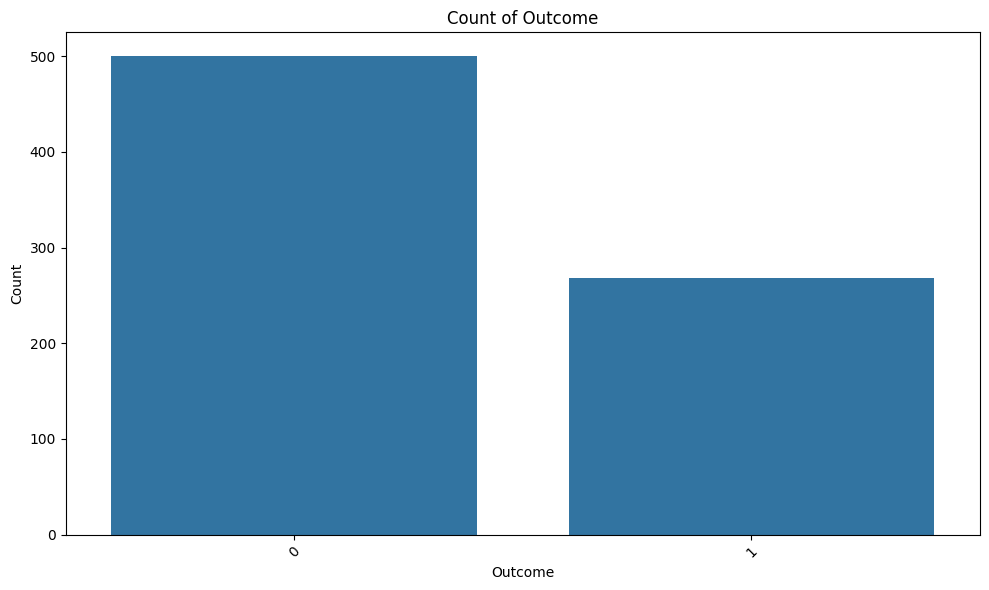

In [ ]:
# ============================================================
# 62. PLOT TARGET CLASS DISTRIBUTION
# ============================================================

plot_count_chart(
    cleaned_data,
    "Outcome"
)

In [ ]:
# ============================================================
# 63. CORRELATION ANALYSIS
# ============================================================

correlation_analysis(
    cleaned_data
)

Correlation Matrix:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


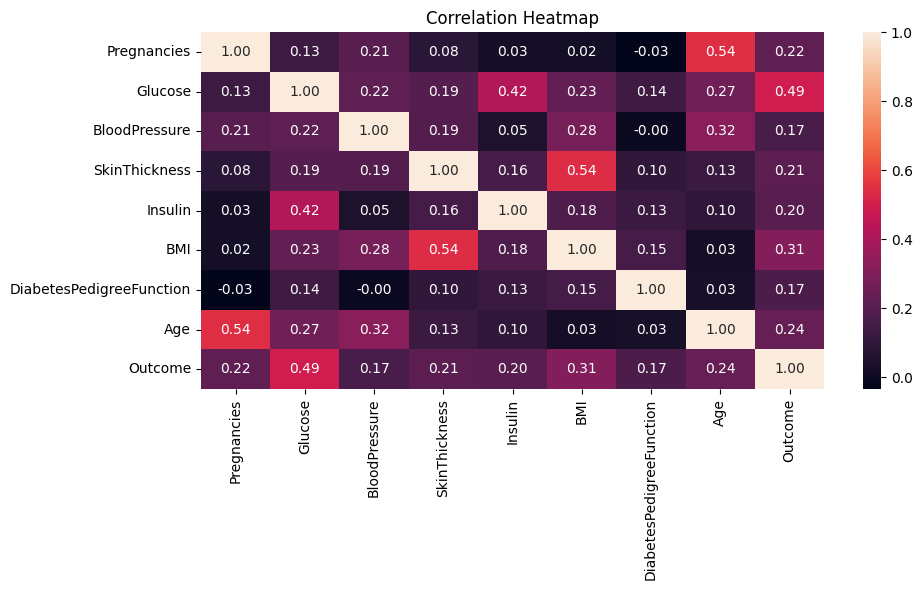

In [ ]:
# ============================================================
# 64. CORRELATION HEATMAP
# ============================================================

plot_correlation_heatmap(
    cleaned_data
)

In [ ]:
# ============================================================
# 65. RUN CLASSIFICATION MODELS
# ============================================================

classification_results = classification_pipeline(
    cleaned_data,
    "Outcome"
)

Likely Identifier Columns:
[]
Machine Learning Data Prepared

Target Column:
Outcome

Feature Shape:
(768, 8)

Target Shape:
(768,)


In [ ]:
# ============================================================
# 66. DETAILED CLASSIFICATION EVALUATION
# ============================================================

# Prepare the data
X, y = prepare_ml_data(
    cleaned_data,
    "Outcome"
)


# ------------------------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# SCALE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ------------------------------------------------------------
# TRAIN LOGISTIC REGRESSION
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)


# ------------------------------------------------------------
# MAKE PREDICTIONS
# ------------------------------------------------------------

predictions = model.predict(
    X_test_scaled
)


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("Classification Report:")

print(
    classification_report(
        y_test,
        predictions
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

conf_matrix = confusion_matrix(
    y_test,
    predictions
)

print("\nConfusion Matrix:")

print(
    conf_matrix
)

Likely Identifier Columns:
[]
Machine Learning Data Prepared

Target Column:
Outcome

Feature Shape:
(768, 8)

Target Shape:
(768,)
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Confusion Matrix:
[[82 18]
 [27 27]]


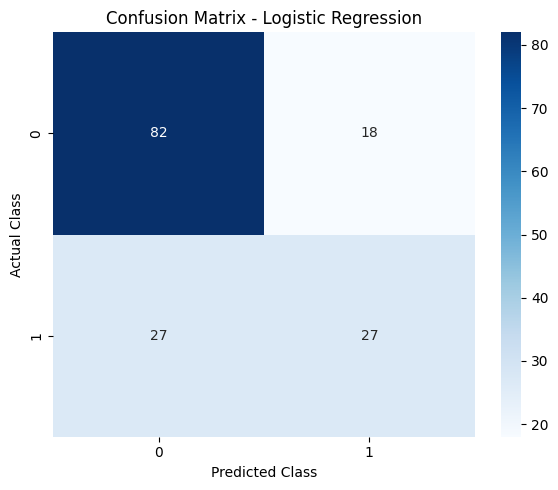

In [ ]:
# ============================================================
# 67. VISUALIZE CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)


# ------------------------------------------------------------
# ADD LABELS AND TITLE
# ------------------------------------------------------------

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)


# ------------------------------------------------------------
# DISPLAY PLOT
# ------------------------------------------------------------

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 68. IMPORT ROC-AUC METRICS
# ============================================================

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

ROC-AUC Score: 0.813


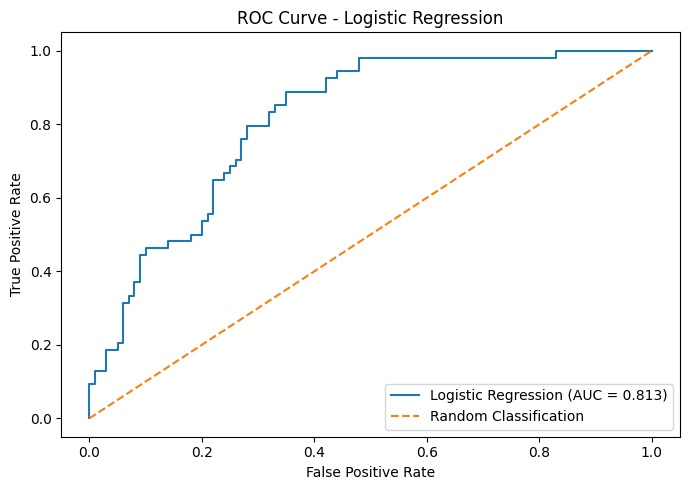

In [ ]:
# ============================================================
# 69. ROC CURVE AND AUC SCORE
# ============================================================

# ------------------------------------------------------------
# GET PROBABILITY OF CLASS 1
# ------------------------------------------------------------

prediction_probabilities = model.predict_proba(
    X_test_scaled
)[:, 1]


# ------------------------------------------------------------
# CALCULATE AUC SCORE
# ------------------------------------------------------------

auc_score = roc_auc_score(
    y_test,
    prediction_probabilities
)

print(
    "ROC-AUC Score:",
    round(auc_score, 4)
)


# ------------------------------------------------------------
# CALCULATE ROC CURVE VALUES
# ------------------------------------------------------------

false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    prediction_probabilities
)


# ------------------------------------------------------------
# CREATE ROC CURVE
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classification"
)


# ------------------------------------------------------------
# ADD LABELS AND TITLE
# ------------------------------------------------------------

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.legend()


# ------------------------------------------------------------
# DISPLAY PLOT
# ------------------------------------------------------------

plt.tight_layout()

plt.show()

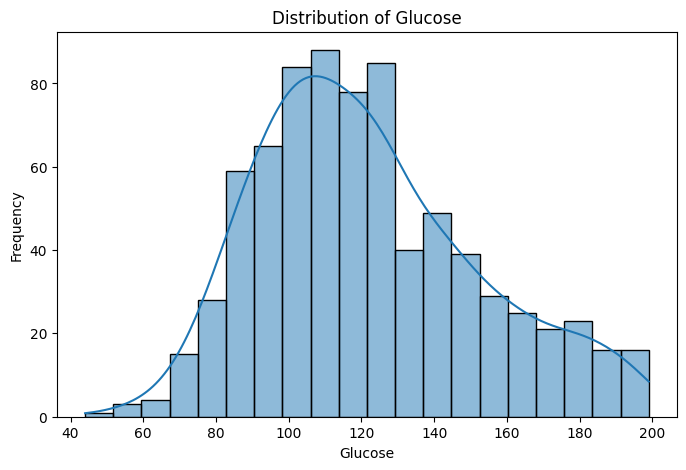

In [ ]:
# ============================================================
# 70. TEST CHAT WITH DATA - VISUALIZATION
# ============================================================

result = chat_with_data(
    "Show the distribution of Glucose",
    cleaned_data
)

if result is not None:

    display(result)

In [ ]:
# ============================================================
# 71. TEST CHAT WITH DATA - CLASSIFICATION
# ============================================================

result = chat_with_data(
    "Build a classification model to predict Outcome",
    cleaned_data
)

if result is not None:

    display(result)

Likely Identifier Columns:
[]
Machine Learning Data Prepared

Target Column:
Outcome

Feature Shape:
(768, 8)

Target Shape:
(768,)


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.7792,0.7745,0.7792,0.7732
1,XGBoost,0.7727,0.7681,0.7727,0.7687
2,KNN,0.7532,0.7497,0.7532,0.7509
3,Logistic Regression,0.7078,0.6989,0.7078,0.7008
4,Decision Tree,0.6818,0.6734,0.6818,0.6762


In [ ]:
# ============================================================
# 72. TEST CHAT WITH DATA - REGRESSION
# ============================================================

result = chat_with_data(
    "Build a regression model to predict BMI",
    cleaned_data
)

if result is not None:

    display(result)

Likely Identifier Columns:
[]
Machine Learning Data Prepared

Target Column:
BMI

Feature Shape:
(768, 8)

Target Shape:
(768,)


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4.4753,33.9171,5.8238,0.2245
1,Random Forest,4.8271,36.7926,6.0657,0.1588
2,XGBoost,4.9338,37.5878,6.1309,0.1406
3,KNN,5.0479,37.6973,6.1398,0.1381
4,Decision Tree,6.0831,62.3701,7.8975,-0.4260



Question: How many rows are in the dataset?


'The dataset contains 768 rows.'


Question: What is the average Glucose?


'The average Glucose is 121.66.'


Question: What is the total Pregnancies?


'The total Pregnancies is 2,953.00.'


Question: Show the distribution of BMI


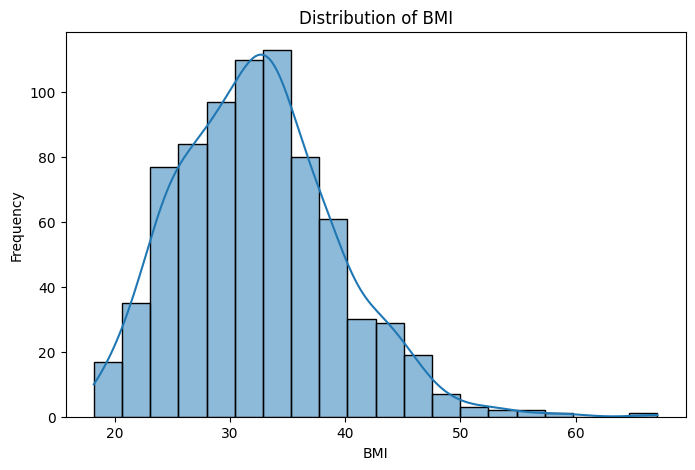


Question: Plot Glucose vs BMI


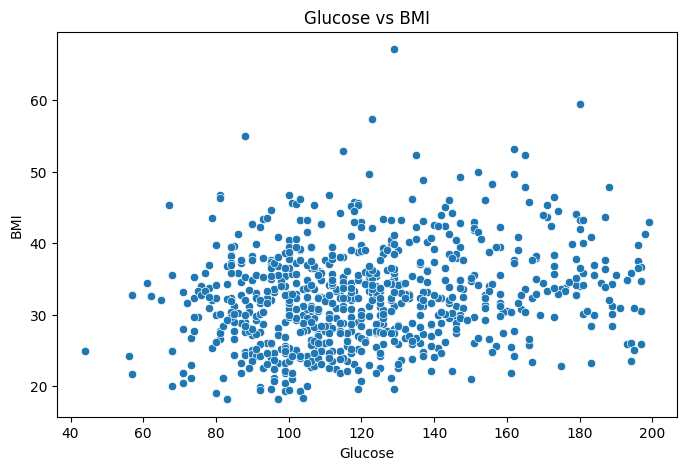


Question: What is the correlation between Glucose and BMI?


'The correlation between Glucose and BMI is 0.231.'


Question: Show the correlation heatmap


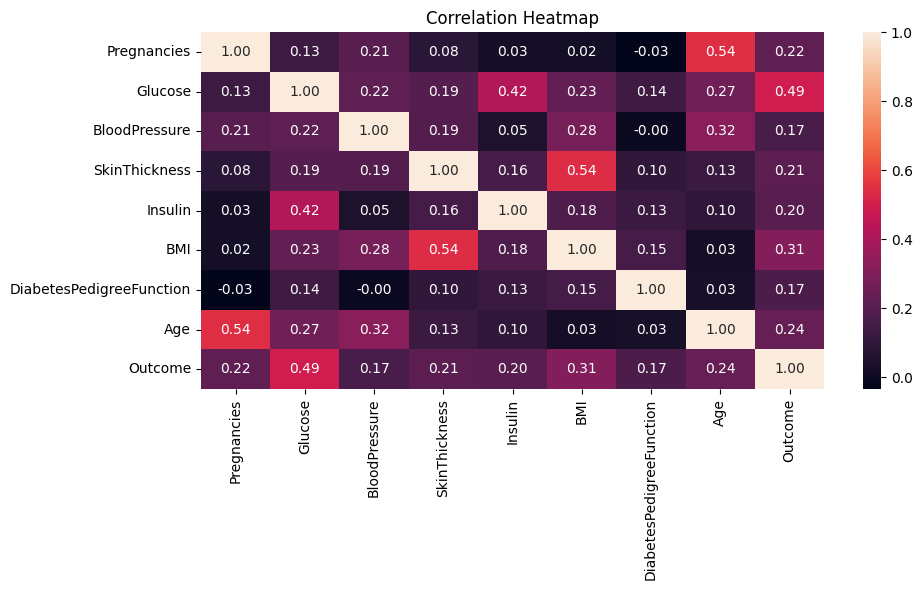


Question: Show missing values


,Column,Missing Values,Missing Percentage
0,Pregnancies,0,0.0
1,Glucose,0,0.0
2,BloodPressure,0,0.0
3,SkinThickness,0,0.0
4,Insulin,0,0.0
5,BMI,0,0.0
6,DiabetesPedigreeFunction,0,0.0
7,Age,0,0.0
8,Outcome,0,0.0


,Column,Missing Values,Missing Percentage
0,Pregnancies,0,0.0
1,Glucose,0,0.0
2,BloodPressure,0,0.0
3,SkinThickness,0,0.0
4,Insulin,0,0.0
5,BMI,0,0.0
6,DiabetesPedigreeFunction,0,0.0
7,Age,0,0.0
8,Outcome,0,0.0



Question: Show outliers


,Column,Outlier Count,Lower Limit,Upper Limit
0,Pregnancies,4,-6.500,13.500
1,Glucose,0,39.000,201.000
2,BloodPressure,14,40.000,104.000
3,SkinThickness,87,14.500,42.500
4,Insulin,346,112.875,135.875
5,BMI,8,13.850,50.250
6,DiabetesPedigreeFunction,29,-0.330,1.200
7,Age,9,-1.500,66.500
8,Outcome,0,-1.500,2.500


,Column,Outlier Count,Lower Limit,Upper Limit
0,Pregnancies,4,-6.500,13.500
1,Glucose,0,39.000,201.000
2,BloodPressure,14,40.000,104.000
3,SkinThickness,87,14.500,42.500
4,Insulin,346,112.875,135.875
5,BMI,8,13.850,50.250
6,DiabetesPedigreeFunction,29,-0.330,1.200
7,Age,9,-1.500,66.500
8,Outcome,0,-1.500,2.500


In [ ]:
# ============================================================
# 73. TEST MULTIPLE CHAT WITH DATA QUESTIONS
# ============================================================

test_questions = [

    "How many rows are in the dataset?",

    "What is the average Glucose?",

    "What is the total Pregnancies?",

    "Show the distribution of BMI",

    "Plot Glucose vs BMI",

    "What is the correlation between Glucose and BMI?",

    "Show the correlation heatmap",

    "Show missing values",

    "Show outliers"

]


# ------------------------------------------------------------
# RUN EACH QUESTION
# ------------------------------------------------------------

for question in test_questions:

    print("\n" + "=" * 60)

    print(
        "Question:",
        question
    )

    print("=" * 60)

    try:

        result = chat_with_data(
            question,
            cleaned_data
        )

        if result is not None:

            display(
                result
            )

    except Exception as error:

        print(
            "Error:",
            error
        )


In [ ]:
# ============================================================
# PART 7 - FINAL BACKEND WORKFLOW
# ============================================================


# ============================================================
# 74. FUNCTION: PREPARE DATASET FOR ANALYSIS
# ============================================================

def prepare_dataset_for_analysis(
    data,
    zero_columns=None
):

    """
    Prepare a dataset for analysis.

    Steps:
    1. Standardize column names
    2. Remove duplicate rows
    3. Replace text missing-value placeholders
    4. Replace selected invalid zero values with NaN
    5. Detect date columns
    6. Fill missing values
    7. Return the cleaned dataset
    """

    # Create a copy so the original data remains unchanged
    cleaned_data = data.copy()


    # --------------------------------------------------------
    # STEP 1: STANDARDIZE COLUMN NAMES
    # --------------------------------------------------------

    cleaned_data = standardize_column_names(
        cleaned_data
    )


    # --------------------------------------------------------
    # STEP 2: REMOVE DUPLICATE ROWS
    # --------------------------------------------------------

    cleaned_data, duplicate_count = remove_duplicate_rows(
        cleaned_data
    )


    # --------------------------------------------------------
    # STEP 3: REPLACE MISSING VALUE PLACEHOLDERS
    # --------------------------------------------------------

    cleaned_data = replace_missing_placeholders(
        cleaned_data
    )


    # --------------------------------------------------------
    # STEP 4: HANDLE INVALID ZERO VALUES
    # --------------------------------------------------------

    if zero_columns is not None:

        # Standardize the supplied column names
        zero_columns = [
            str(column)
            .strip()
            .lower()
            .replace(" ", "_")
            .replace("-", "_")

            for column in zero_columns
        ]

        cleaned_data = replace_invalid_zero_values(
            cleaned_data,
            zero_columns
        )


    # --------------------------------------------------------
    # STEP 5: DETECT DATE COLUMNS
    # --------------------------------------------------------

    cleaned_data, date_columns = detect_date_columns(
        cleaned_data
    )


    # --------------------------------------------------------
    # STEP 6: FILL MISSING VALUES
    # --------------------------------------------------------

    cleaned_data = fill_missing_values(
        cleaned_data
    )


    # --------------------------------------------------------
    # CLEANING SUMMARY
    # --------------------------------------------------------

    cleaning_summary = {

        "rows": cleaned_data.shape[0],

        "columns": cleaned_data.shape[1],

        "duplicates_removed": int(
            duplicate_count
        ),

        "remaining_missing_values": int(
            cleaned_data.isnull().sum().sum()
        ),

        "date_columns": date_columns

    }


    # --------------------------------------------------------
    # RETURN RESULTS
    # --------------------------------------------------------

    return cleaned_data, cleaning_summary

In [ ]:
# ============================================================
# 75. TEST FINAL DATA PREPARATION FUNCTION
# ============================================================

cleaned_data, cleaning_summary = (
    prepare_dataset_for_analysis(
        data,
        zero_columns=[
            "Glucose",
            "BloodPressure",
            "SkinThickness",
            "Insulin",
            "BMI"
        ]
    )
)


# ------------------------------------------------------------
# DISPLAY CLEANING SUMMARY
# ------------------------------------------------------------

print("Cleaning Summary:")

print(
    cleaning_summary
)


# ------------------------------------------------------------
# DISPLAY CLEANED DATASET
# ------------------------------------------------------------

display(
    cleaned_data.head()
)

Standardized Column Names:
['pregnancies', 'glucose', 'bloodpressure', 'skinthickness', 'insulin', 'bmi', 'diabetespedigreefunction', 'age', 'outcome']
Duplicate Rows Found:
0
Missing value placeholders replaced successfully.
Detected Date Columns:
[]
Missing values filled successfully.
Cleaning Summary:
{'rows': 768, 'columns': 9, 'duplicates_removed': 0, 'remaining_missing_values': 0, 'date_columns': []}


,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
# ============================================================
# 76. VALIDATE FINAL CLEANED DATASET
# ============================================================

validate_cleaned_dataset(
    cleaned_data
)

Cleaned Dataset Shape:
(768, 9)

Remaining Missing Values:
pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
outcome                     0
dtype: int64

Total Remaining Missing Values:
0

Remaining Duplicate Rows:
0

Final Data Types:
pregnancies                   int64
glucose                     float64
bloodpressure               float64
skinthickness               float64
insulin                     float64
bmi                         float64
diabetespedigreefunction    float64
age                           int64
outcome                       int64
dtype: object

Cleaned Dataset Preview:


,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


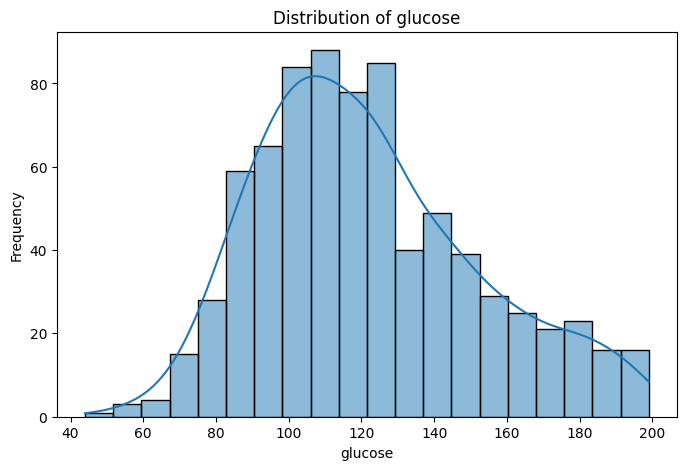

In [ ]:
# ============================================================
# 77. TEST CHAT WITH FINAL CLEANED DATA
# ============================================================

result = chat_with_data(
    "Show the distribution of glucose",
    cleaned_data
)

if result is not None:

    display(result)

In [ ]:
# ============================================================
# 78. TEST CLASSIFICATION WITH FINAL CLEANED DATA
# ============================================================

result = chat_with_data(
    "Build a classification model to predict outcome",
    cleaned_data
)

if result is not None:

    display(result)

Likely Identifier Columns:
[]
Machine Learning Data Prepared

Target Column:
outcome

Feature Shape:
(768, 8)

Target Shape:
(768,)


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.7792,0.7745,0.7792,0.7732
1,XGBoost,0.7727,0.7681,0.7727,0.7687
2,KNN,0.7532,0.7497,0.7532,0.7509
3,Logistic Regression,0.7078,0.6989,0.7078,0.7008
4,Decision Tree,0.6818,0.6734,0.6818,0.6762


In [ ]:
# ============================================================
# 79. FUNCTION: AUTOMATIC ML PROBLEM TYPE DETECTION
# ============================================================

def detect_ml_problem_type(
    data,
    target_column
):

    """
    Detect whether the machine learning task
    should be classification or regression.

    Rules:
    - Non-numeric target → classification
    - Numeric target with few unique values → classification
    - Numeric continuous target → regression
    """

    # --------------------------------------------------------
    # VALIDATE TARGET COLUMN
    # --------------------------------------------------------

    if target_column not in data.columns:

        raise ValueError(
            f"Target column '{target_column}' does not exist."
        )


    target = data[target_column]


    # --------------------------------------------------------
    # RULE 1: NON-NUMERIC TARGET
    # --------------------------------------------------------

    if not pd.api.types.is_numeric_dtype(
        target
    ):

        return "classification"


    # --------------------------------------------------------
    # RULE 2: NUMERIC BUT DISCRETE TARGET
    # --------------------------------------------------------

    unique_values = target.nunique()


    if unique_values <= 10:

        return "classification"


    # --------------------------------------------------------
    # RULE 3: CONTINUOUS NUMERIC TARGET
    # --------------------------------------------------------

    return "regression"

In [ ]:


# ============================================================
# 80. TEST AUTOMATIC ML PROBLEM TYPE DETECTION
# ============================================================

outcome_problem_type = detect_ml_problem_type(
    cleaned_data,
    "outcome"
)

bmi_problem_type = detect_ml_problem_type(
    cleaned_data,
    "bmi"
)


print(
    "outcome:",
    outcome_problem_type
)

print(
    "bmi:",
    bmi_problem_type
)

outcome: classification
bmi: regression


In [ ]:
# ============================================================
# 82. TEST AUTOMATIC MACHINE LEARNING CONTROLLER
# ============================================================

print("Testing outcome target:")
print("-" * 50)

outcome_results = run_machine_learning(
    operation="auto",
    data=cleaned_data,
    target_column="outcome"
)

display(outcome_results)


print("\nTesting bmi target:")
print("-" * 50)

bmi_results = run_machine_learning(
    operation="auto",
    data=cleaned_data,
    target_column="bmi"
)

display(bmi_results)

Testing outcome target:
--------------------------------------------------
Detected ML problem type: classification
Likely Identifier Columns:
[]
Machine Learning Data Prepared

Target Column:
outcome

Feature Shape:
(768, 8)

Target Shape:
(768,)


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.7792,0.7745,0.7792,0.7732
1,XGBoost,0.7727,0.7681,0.7727,0.7687
2,KNN,0.7532,0.7497,0.7532,0.7509
3,Logistic Regression,0.7078,0.6989,0.7078,0.7008
4,Decision Tree,0.6818,0.6734,0.6818,0.6762



Testing bmi target:
--------------------------------------------------
Detected ML problem type: regression
Likely Identifier Columns:
[]
Machine Learning Data Prepared

Target Column:
bmi

Feature Shape:
(768, 8)

Target Shape:
(768,)


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4.4753,33.9171,5.8238,0.2245
1,Random Forest,4.8271,36.7926,6.0657,0.1588
2,XGBoost,4.9338,37.5878,6.1309,0.1406
3,KNN,5.0479,37.6973,6.1398,0.1381
4,Decision Tree,6.0831,62.3701,7.8975,-0.4260


In [ ]:
# ============================================================
# 86. TEST AUTOMATIC ML THROUGH CHAT
# ============================================================

result = chat_with_data(
    "Predict outcome",
    cleaned_data
)

if result is not None:

    display(result)

Detected ML problem type: classification
Likely Identifier Columns:
[]
Machine Learning Data Prepared

Target Column:
outcome

Feature Shape:
(768, 8)

Target Shape:
(768,)


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.7792,0.7745,0.7792,0.7732
1,XGBoost,0.7727,0.7681,0.7727,0.7687
2,KNN,0.7532,0.7497,0.7532,0.7509
3,Logistic Regression,0.7078,0.6989,0.7078,0.7008
4,Decision Tree,0.6818,0.6734,0.6818,0.6762


In [ ]:
# ============================================================
# 87. TEST AUTOMATIC REGRESSION THROUGH CHAT
# ============================================================

result = chat_with_data(
    "Predict bmi",
    cleaned_data
)

if result is not None:

    display(result)

Detected ML problem type: regression
Likely Identifier Columns:
[]
Machine Learning Data Prepared

Target Column:
bmi

Feature Shape:
(768, 8)

Target Shape:
(768,)


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4.4753,33.9171,5.8238,0.2245
1,Random Forest,4.8271,36.7926,6.0657,0.1588
2,XGBoost,4.9338,37.5878,6.1309,0.1406
3,KNN,5.0479,37.6973,6.1398,0.1381
4,Decision Tree,6.0831,62.3701,7.8975,-0.4260


In [ ]:
# ============================================================
# 89. TEST UPDATED AI INTERPRETER
# ============================================================

plan = interpret_question_with_ai(
    "Show the distribution of glucose",
    cleaned_data
)

print("AI Analysis Plan:")

print(plan)

AI Analysis Plan:
{'operation': 'histogram', 'x_column': 'glucose', 'y_column': None, 'aggregation': None, 'time_grouping': None}


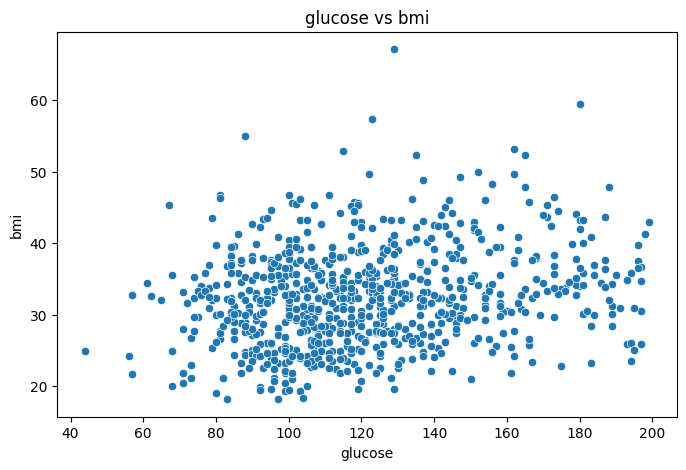

In [ ]:
# ============================================================
# 90. TEST FULL CHAT SYSTEM AFTER AI UPDATE
# ============================================================

result = chat_with_data(
    "Plot glucose vs bmi",
    cleaned_data
)

if result is not None:
    display(result)

TEST 1: HIDE AI PLAN


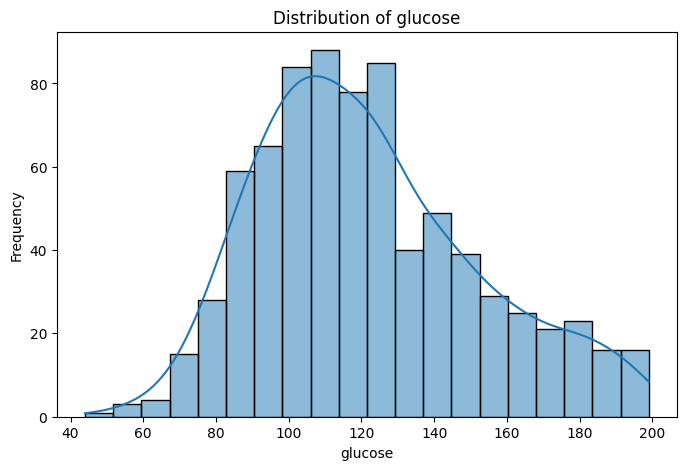


TEST 2: SHOW AI PLAN
AI Analysis Plan:
{
    "operation": "histogram",
    "x_column": "glucose",
    "y_column": null,
    "aggregation": null,
    "time_grouping": null
}


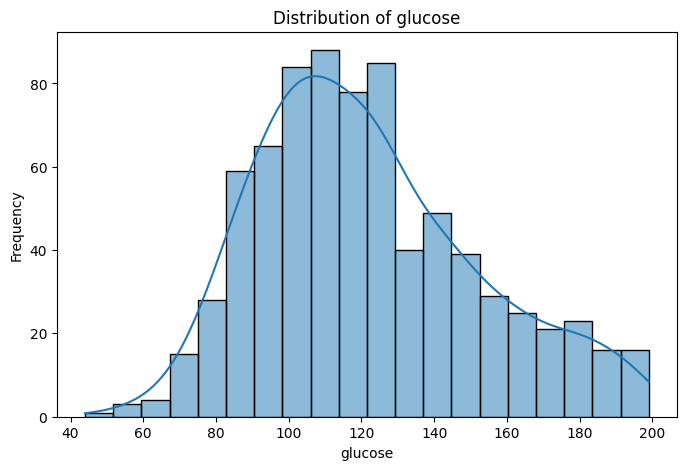

In [ ]:
# ============================================================
# 92. TEST OPTIONAL AI PLAN DISPLAY
# ============================================================

print("TEST 1: HIDE AI PLAN")

result = chat_with_data(
    "Show the distribution of glucose",
    cleaned_data
)

if result is not None:
    display(result)


print("\nTEST 2: SHOW AI PLAN")

result = chat_with_data(
    "Show the distribution of glucose",
    cleaned_data,
    show_plan=True
)

if result is not None:
    display(result)

In [ ]:
# ============================================================
# 95. TEST CHAT ERROR HANDLING
# ============================================================

result = chat_with_data(
    "Plot salary vs age",
    cleaned_data
)

print(result)

The request could not be completed because one or more requested columns do not exist in the dataset.


In [ ]:
# ============================================================
# 99. TEST INVALID REQUEST HANDLING
# ============================================================

result = chat_with_data(
    "Plot salary vs age",
    cleaned_data,
    show_plan=True
)

print(result)

AI Analysis Plan:
{
    "operation": "invalid_request",
    "x_column": null,
    "y_column": null,
    "aggregation": null,
    "time_grouping": null
}
The request could not be completed because one or more requested columns do not exist in the dataset.


AI Analysis Plan:
{
    "operation": "scatter",
    "x_column": "glucose",
    "y_column": "bmi",
    "aggregation": null,
    "time_grouping": null
}


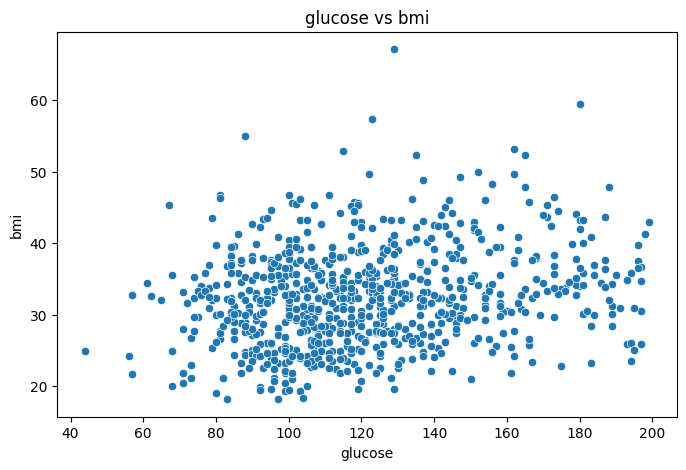

In [ ]:
# ============================================================
# 100. FINAL VALID CHAT TEST
# ============================================================

result = chat_with_data(
    "Plot glucose vs bmi",
    cleaned_data,
    show_plan=True
)

if result is not None:
    display(result)